
# EV01 Battery Pack Diagnostic Notebook
## Founder Review Version — Master Dataset Analysis (VCU + Pack + Module)

This notebook is designed to be run **cell by cell** and presented directly to leadership.

It explains:
- what each analysis step does
- why the step matters for an **electric excavator**
- what patterns are visible in the data
- why **Module 1** is emerging as the main suspect
- under what operating conditions cell imbalance becomes worse

---

## Scope of this notebook

This notebook covers the analysis completed so far:

1. Load and validate the EV01 master dataset  
2. Create analysis-ready canonical features  
3. Inspect core distributions  
4. Remove physically implausible artifact rows  
5. Compare behavior by SOC and charge/discharge direction  
6. Show module-level evidence that **Module 1 is persistently abnormal**  
7. Show excavator-specific high-load behavior  
8. Show that **low SOC + discharge + high load** is the strongest real stress condition  
9. Separate **balancing-like charge behavior** from real under-load weakness  
10. Produce trip-level and daily-level evidence for review

---

## Why this notebook is excavator-specific

This is **not** a passenger EV analysis.

For an electric excavator:
- long periods of stationary but heavy electrical load are normal
- high current can happen at low travel speed
- thermal load can build during repeated hydraulic duty cycles
- charging/balancing behavior must be separated from true under-load pack weakness

So the goal here is not “range estimation.”  
The goal is to answer:

> **Which part of the pack looks weak, and under what excavator operating conditions does that weakness show up most clearly?**


In [1]:

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("Libraries loaded.")


Libraries loaded.



## 1) Configure dataset location and date range

This cell sets:
- where the master parquet dataset lives
- what date range to load
- which vehicle ID to analyze

If your project root differs, update `MASTER_ROOT`.


In [2]:

MASTER_ROOT_CANDIDATES = [
    Path("data/analysis/master"),
    Path("../data/analysis/master"),
    Path("../../data/analysis/master"),
    Path("/workspace/data/analysis/master"),
]

START_DATE = "2026-01-22"
END_DATE = "2026-03-08"
VEHICLE_ID = "EV01"

def resolve_master_root(candidates):
    for p in candidates:
        if p.exists():
            return p.resolve()
    return candidates[0].resolve()

MASTER_ROOT = resolve_master_root(MASTER_ROOT_CANDIDATES)
print("Resolved MASTER_ROOT:", MASTER_ROOT)
print("Exists:", MASTER_ROOT.exists())


Resolved MASTER_ROOT: /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/analysis/master
Exists: True



## 2) Load all EV01 partitions

This cell:
- searches the requested date range
- loads every matching parquet partition
- reports missing partitions
- concatenates everything into one dataframe

This is the raw analysis base.


In [3]:

def load_master_dataset(start_date, end_date, vehicle_id, root):
    dates = pd.date_range(start_date, end_date, freq="D")
    paths = []
    missing = []

    for d in dates:
        p = root / f"dt={d.date()}" / f"vehicle_id={vehicle_id}.parquet"
        if p.exists():
            paths.append(p)
        else:
            missing.append(str(p))

    print("Found", len(paths), "partition files")
    print("Missing", len(missing), "partition files")
    if missing:
        print("First few missing:")
        for m in missing[:5]:
            print("  -", m)

    if not paths:
        raise FileNotFoundError("No parquet partitions found. Check MASTER_ROOT / date range / vehicle_id.")

    frames = [pd.read_parquet(p) for p in paths]
    df = pd.concat(frames, ignore_index=True)
    return df, paths, missing

df, loaded_paths, missing_paths = load_master_dataset(
    START_DATE, END_DATE, VEHICLE_ID, MASTER_ROOT
)

print("Loaded shape:", df.shape)
print("Columns:", len(df.columns))
df.head(3)


Found 39 partition files
Missing 7 partition files
First few missing:
  - /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/analysis/master/dt=2026-02-27/vehicle_id=EV01.parquet
  - /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/analysis/master/dt=2026-02-28/vehicle_id=EV01.parquet
  - /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/analysis/master/dt=2026-03-02/vehicle_id=EV01.parquet
  - /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/analysis/master/dt=2026-03-03/vehicle_id=EV01.parquet
  - /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/analysis/master/dt=2026-03-05/vehicle_id=EV01.parquet
Loaded shape: (744618, 68)
Columns: 68


,timestamp,vehicle_id,trip_id,soc_pct,battery_current_a,stack_voltage_v,output_power_kw,max_cell_voltage_v,min_cell_voltage_v,avg_cell_voltage_v,avg_battery_temp_c,max_battery_temp_c,min_battery_temp_c,motor_speed_rpm,motor_torque_value_nm,motor_temperature_c,battery_status,fault_any,vcu_quality_flag,pack_voltage_range,pack_voltage_std,worst_cell_id,imbalance_flag,pack_temp_range,hottest_module_id,module_1_voltage_mean,module_1_voltage_std,module_1_voltage_range,module_1_lowest_cell,module_1_temp_mean,module_1_temp_range,module_1_hottest_sensor,module_2_voltage_mean,module_2_voltage_std,module_2_voltage_range,module_2_lowest_cell,module_2_temp_mean,module_2_temp_range,module_2_hottest_sensor,module_3_voltage_mean,module_3_voltage_std,module_3_voltage_range,module_3_lowest_cell,module_3_temp_mean,module_3_temp_range,module_3_hottest_sensor,module_4_voltage_mean,module_4_voltage_std,module_4_voltage_range,module_4_lowest_cell,module_4_temp_mean,module_4_temp_range,module_4_hottest_sensor,module_5_voltage_mean,module_5_voltage_std,module_5_voltage_range,module_5_lowest_cell,module_5_temp_mean,module_5_temp_range,module_5_hottest_sensor,cell_quality_flag,dt,cell_spread_v,abs_current_a,current_direction,soc_band,operating_regime,is_clean
0,2026-01-22 15:21:36,EV01,EV01_000833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,879.0,48.0,NaN,Discharging,0,2,0.004,0.001164,M3_C25,0,NaN,<NA>,NaN,NaN,NaN,None,NaN,NaN,None,3.304625,0.000744,0.002,M2_C5,NaN,NaN,None,3.303125,0.000641,0.002,M3_C25,NaN,NaN,None,3.302125,0.000354,0.001,M4_C5,NaN,NaN,None,3.303125,0.001126,0.003,M5_C1,NaN,NaN,None,2,2026-01-22,NaN,NaN,idle,NaN,idle,True
1,2026-01-22 15:21:37,EV01,EV01_000833,72.0,13.0,590.775,7.680,NaN,NaN,NaN,NaN,NaN,NaN,876.0,48.0,NaN,Discharging,0,2,0.005,0.001277,M4_C25,0,20.0,1,3.305375,0.000518,0.001,M1_C13,35.5,17.0,M1_T18,3.304583,0.000669,0.002,M2_C5,27.000000,8.0,M2_T6,3.303375,0.000744,0.002,M3_C25,25.666667,9.0,M3_T18,3.302375,0.000619,0.002,M4_C25,24.0,0.0,M4_T1,3.303083,0.000900,0.003,M5_C1,27.0,8.0,M5_T12,2,2026-01-22,NaN,13.0,discharge,60-80,light_discharge,True
2,2026-01-22 15:21:38,EV01,EV01_000833,72.0,11.0,590.815,6.499,NaN,NaN,NaN,NaN,NaN,NaN,877.5,48.0,0.0,Discharging,0,2,0.006,0.001342,M4_C25,0,20.0,1,3.305875,0.000641,0.002,M1_C29,35.5,17.0,M1_T18,3.304583,0.000793,0.003,M2_C25,27.333333,7.0,M2_T6,3.303167,0.000577,0.002,M3_C25,25.666667,9.0,M3_T18,3.302563,0.000629,0.002,M4_C25,24.0,0.0,M4_T1,3.303000,0.000953,0.003,M5_C1,27.0,8.0,M5_T12,2,2026-01-22,NaN,11.0,discharge,60-80,light_discharge,True



## 3) Confirm core schema and create canonical analysis columns

The master dataset contains:
- VCU columns
- pack-level columns
- per-module columns

To make the notebook easier to read, we create canonical aliases:
- `soc`
- `current`
- `abs_current`
- `cell_spread`
- `temp_range`
- `pack_v_std`
- `trip`
- `hottest_module`

We also derive:
- `soc_band`
- `current_direction`

This keeps the rest of the notebook readable for non-technical review.


In [4]:

VCU_COLS = [
    "timestamp", "vehicle_id", "trip_id", "soc_pct", "battery_current_a",
    "stack_voltage_v", "output_power_kw", "max_cell_voltage_v", "min_cell_voltage_v",
    "avg_cell_voltage_v", "avg_battery_temp_c", "max_battery_temp_c", "min_battery_temp_c",
    "motor_speed_rpm", "motor_torque_value_nm", "motor_temperature_c",
    "battery_status", "fault_any", "quality_flag",
]

PACK_COLS = [
    "timestamp", "vehicle_id", "cell_quality_flag", "pack_voltage_range",
    "pack_voltage_std", "worst_cell_id", "imbalance_flag", "pack_temp_range",
    "hottest_module_id",
]

MODULE_COLS = [
    "timestamp", "vehicle_id", "cell_quality_flag",
    "module_1_voltage_mean", "module_1_voltage_std", "module_1_voltage_range", "module_1_lowest_cell", "module_1_temp_mean", "module_1_temp_range", "module_1_hottest_sensor",
    "module_2_voltage_mean", "module_2_voltage_std", "module_2_voltage_range", "module_2_lowest_cell", "module_2_temp_mean", "module_2_temp_range", "module_2_hottest_sensor",
    "module_3_voltage_mean", "module_3_voltage_std", "module_3_voltage_range", "module_3_lowest_cell", "module_3_temp_mean", "module_3_temp_range", "module_3_hottest_sensor",
    "module_4_voltage_mean", "module_4_voltage_std", "module_4_voltage_range", "module_4_lowest_cell", "module_4_temp_mean", "module_4_temp_range", "module_4_hottest_sensor",
    "module_5_voltage_mean", "module_5_voltage_std", "module_5_voltage_range", "module_5_lowest_cell", "module_5_temp_mean", "module_5_temp_range", "module_5_hottest_sensor",
]

present_vcu = [c for c in VCU_COLS if c in df.columns]
present_pack = [c for c in PACK_COLS if c in df.columns]
present_module = [c for c in MODULE_COLS if c in df.columns]

print("Present VCU cols:", len(present_vcu))
print("Present PACK cols:", len(present_pack))
print("Present MODULE cols:", len(present_module))

analysis_df = df.copy()

analysis_df["timestamp"] = pd.to_datetime(analysis_df["timestamp"], errors="coerce")
analysis_df["date"] = analysis_df["timestamp"].dt.date

analysis_df["soc"] = analysis_df["soc_pct"]
analysis_df["current"] = analysis_df["battery_current_a"]
analysis_df["abs_current"] = analysis_df["battery_current_a"].abs()
analysis_df["cell_spread"] = analysis_df["max_cell_voltage_v"] - analysis_df["min_cell_voltage_v"]
analysis_df["pack_v_std"] = analysis_df["pack_voltage_std"]
analysis_df["temp_range"] = analysis_df["pack_temp_range"]
analysis_df["trip"] = analysis_df["trip_id"]
analysis_df["hottest_module"] = analysis_df["hottest_module_id"]

analysis_df["soc_band"] = pd.cut(
    analysis_df["soc"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20", "20-40", "40-60", "60-80", "80-100"],
    include_lowest=True,
)

analysis_df["current_direction"] = np.where(
    analysis_df["current"] > 0, "discharge", "charge"
)

module_voltage_cols = [f"module_{i}_voltage_mean" for i in range(1, 6)]
module_temp_cols = [f"module_{i}_temp_mean" for i in range(1, 6)]

analysis_df["lowest_voltage_module"] = (
    analysis_df[module_voltage_cols]
    .idxmin(axis=1)
    .str.extract(r"module_(\d+)_")[0]
    .astype("Int64")
)

analysis_df["highest_temp_module_from_means"] = (
    analysis_df[module_temp_cols]
    .idxmax(axis=1)
    .str.extract(r"module_(\d+)_")[0]
    .astype("Int64")
)

print("Canonical columns created.")
analysis_df[[
    "timestamp", "soc", "current", "abs_current", "cell_spread",
    "pack_v_std", "temp_range", "trip", "hottest_module",
    "lowest_voltage_module", "soc_band", "current_direction"
]].head(5)


Present VCU cols: 18
Present PACK cols: 9
Present MODULE cols: 38


/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_21833/2421348123.py:62: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin(axis=1)
/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_21833/2421348123.py:69: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmax(axis=1)


Canonical columns created.


,timestamp,soc,current,abs_current,cell_spread,pack_v_std,temp_range,trip,hottest_module,lowest_voltage_module,soc_band,current_direction
0,2026-01-22 15:21:36,NaN,NaN,NaN,NaN,0.001164,NaN,EV01_000833,<NA>,4,NaN,charge
1,2026-01-22 15:21:37,72.0,13.0,13.0,NaN,0.001277,20.0,EV01_000833,1,4,60-80,discharge
2,2026-01-22 15:21:38,72.0,11.0,11.0,NaN,0.001342,20.0,EV01_000833,1,4,60-80,discharge
3,2026-01-22 15:21:39,72.0,13.0,13.0,NaN,0.006831,20.0,EV01_000833,1,1,60-80,discharge
4,2026-01-22 15:21:40,72.0,13.0,13.0,NaN,0.005896,20.0,EV01_000833,1,4,60-80,discharge



## 4) First-pass high-level stats

This gives leadership a quick snapshot of the full dataset:
- row count
- date coverage
- trip count
- key signal ranges

This is useful to show analysis coverage before discussing diagnosis.


In [5]:

summary = {
    "rows": len(analysis_df),
    "date_min": analysis_df["timestamp"].min(),
    "date_max": analysis_df["timestamp"].max(),
    "unique_dates": analysis_df["date"].nunique(),
    "unique_trips": analysis_df["trip"].nunique(),
    "soc_min": analysis_df["soc"].min(),
    "soc_max": analysis_df["soc"].max(),
    "current_min": analysis_df["current"].min(),
    "current_max": analysis_df["current"].max(),
    "cell_spread_min": analysis_df["cell_spread"].min(),
    "cell_spread_max": analysis_df["cell_spread"].max(),
    "temp_range_min": analysis_df["temp_range"].min(),
    "temp_range_max": analysis_df["temp_range"].max(),
}
pd.Series(summary)


rows                            744618
date_min           2026-01-22 15:21:36
date_max           2026-03-08 22:26:42
unique_dates                        46
unique_trips                       352
soc_min                            0.0
soc_max                          100.0
current_min                        0.0
current_max                     1451.0
cell_spread_min                    0.0
cell_spread_max                  3.385
temp_range_min                     1.0
temp_range_max                   117.0
dtype: object


## 5) Visualize overall distributions

These plots show the natural operating range and outliers for:
- cell spread
- pack voltage standard deviation
- pack temperature range
- absolute current
- SOC

This is the first step in seeing whether the pack has a long tail of stress behavior.


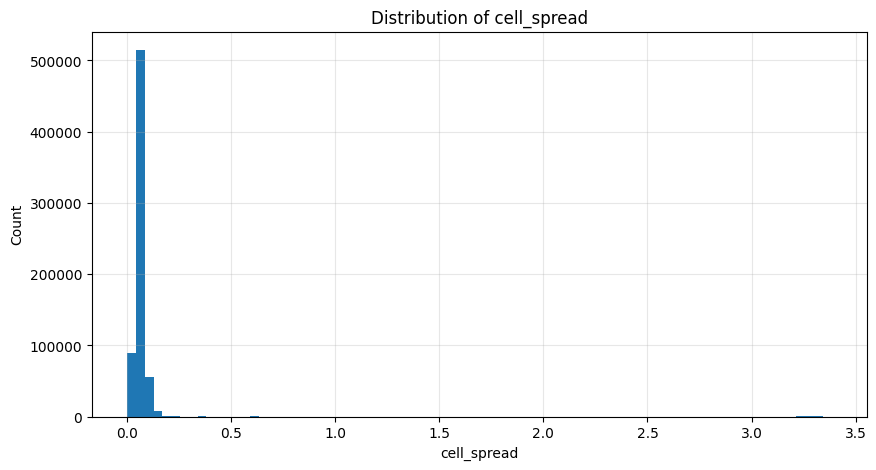

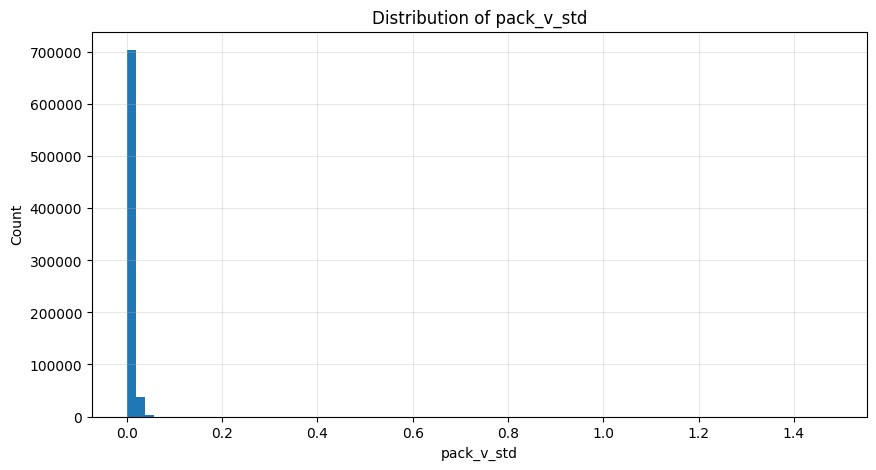

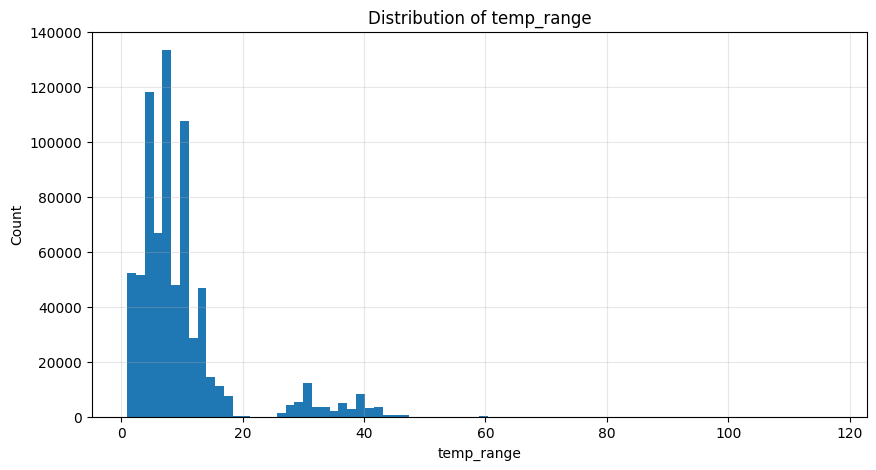

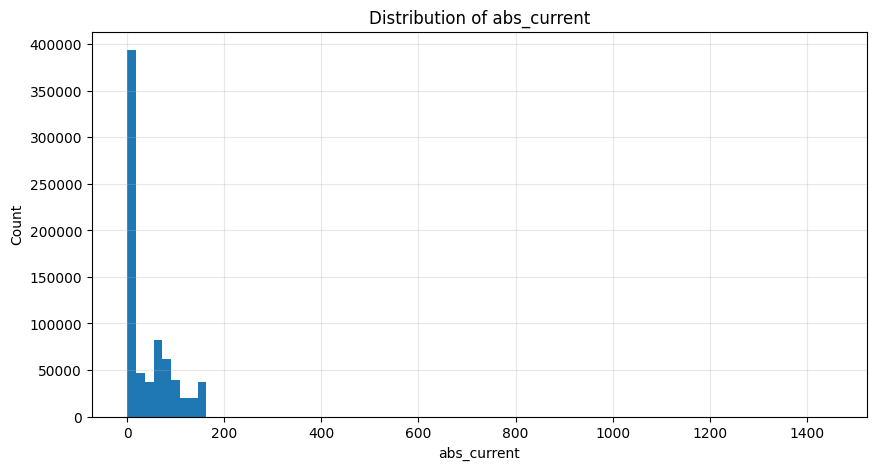

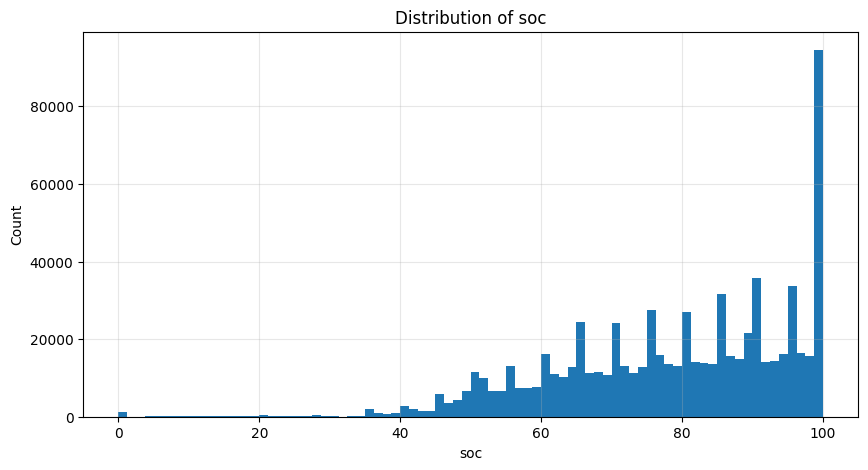

,cell_spread,pack_v_std,temp_range,abs_current,soc
count,670056.000000,744614.000000,744617.000000,736932.000000,738959.000000
mean,0.062366,0.010963,9.743542,42.187401,78.669065
std,0.104892,0.006274,8.186492,44.645273,16.652552
min,0.000000,0.000554,1.000000,0.000000,0.000000
50%,0.057000,0.010928,8.000000,16.000000,81.000000
90%,0.084000,0.016300,16.000000,113.000000,99.000000
95%,0.100000,0.019635,31.000000,145.000000,99.000000
99%,0.138000,0.032379,41.000000,150.000000,100.000000
max,3.385000,1.479410,117.000000,1451.000000,100.000000


In [6]:

plot_cols = ["cell_spread", "pack_v_std", "temp_range", "abs_current", "soc"]

for c in plot_cols:
    plt.figure()
    analysis_df[c].dropna().hist(bins=80)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

analysis_df[plot_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


In [7]:
# Identify suspicious artifact rows
artifact_candidates = analysis_df[
    (analysis_df["min_cell_voltage_v"] <= 0.05) &
    (analysis_df["max_cell_voltage_v"] >= 3.0) &
    (analysis_df["cell_spread"] >= 1.0)
].copy()

print("Total rows:", len(analysis_df))
print("Artifact candidate rows:", len(artifact_candidates))
print("Fraction:", len(artifact_candidates) / len(analysis_df))

# Show top examples sorted by spread
display(
    artifact_candidates[
        [
            "timestamp",
            "trip",
            "soc",
            "current",
            "cell_spread",
            "max_cell_voltage_v",
            "min_cell_voltage_v",
            "pack_v_std",
            "temp_range",
            "hottest_module",
            "cell_quality_flag",
        ]
    ]
    .sort_values("cell_spread", ascending=False)
    .head(50)
)

Total rows: 744618
Artifact candidate rows: 667
Fraction: 0.0008957613165408303


,timestamp,trip,soc,current,cell_spread,max_cell_voltage_v,min_cell_voltage_v,pack_v_std,temp_range,hottest_module,cell_quality_flag
408512,2026-02-16 02:27:30,EV01_001019,98.0,63.0,3.385,3.385,0.0,0.011140,5.0,1,32
408521,2026-02-16 02:27:48,EV01_001019,98.0,63.0,3.385,3.385,0.0,0.011136,5.0,1,32
408529,2026-02-16 02:28:04,EV01_001019,98.0,59.0,3.385,3.385,0.0,0.011079,5.0,1,32
408528,2026-02-16 02:28:02,EV01_001019,98.0,59.0,3.385,3.385,0.0,0.011108,5.0,1,32
408526,2026-02-16 02:27:58,EV01_001019,98.0,58.0,3.385,3.385,0.0,0.011105,5.0,1,32
408525,2026-02-16 02:27:56,EV01_001019,98.0,58.0,3.385,3.385,0.0,0.011153,5.0,1,32
408524,2026-02-16 02:27:54,EV01_001019,98.0,58.0,3.385,3.385,0.0,0.011179,5.0,1,32
408523,2026-02-16 02:27:52,EV01_001019,98.0,63.0,3.385,3.385,0.0,0.011163,5.0,1,32
408522,2026-02-16 02:27:50,EV01_001019,98.0,63.0,3.385,3.385,0.0,0.011143,5.0,1,32
408527,2026-02-16 02:28:00,EV01_001019,98.0,59.0,3.385,3.385,0.0,0.011103,5.0,1,32



## 6) Identify and remove physically implausible spread artifacts

During investigation, we found some rows where:
- `min_cell_voltage_v = 0.0`
- `max_cell_voltage_v ≈ 3.3 V`
- `cell_spread ≈ 3.3 V`

Those are **not physically credible battery imbalance events**.  
They are almost certainly sensor/data artifacts.

So before diagnosing real pack weakness, we filter those rows out.

This is a critical credibility step for founder review.


In [8]:

analysis_df["is_artifact_spread"] = (
    (analysis_df["min_cell_voltage_v"] <= 0.05) &
    (analysis_df["max_cell_voltage_v"] >= 3.0) &
    (analysis_df["cell_spread"] >= 1.0)
)

print("Artifact rows:", int(analysis_df["is_artifact_spread"].sum()))
print("Artifact fraction:", analysis_df["is_artifact_spread"].mean())

artifact_examples = analysis_df.loc[
    analysis_df["is_artifact_spread"],
    [
        "timestamp", "trip", "soc", "current", "cell_spread",
        "max_cell_voltage_v", "min_cell_voltage_v", "pack_v_std",
        "temp_range", "hottest_module", "cell_quality_flag"
    ]
].head(20)

artifact_examples


Artifact rows: 667
Artifact fraction: 0.0008957613165408303


,timestamp,trip,soc,current,cell_spread,max_cell_voltage_v,min_cell_voltage_v,pack_v_std,temp_range,hottest_module,cell_quality_flag
9291,2026-01-23 10:14:48,EV01_000838,78.0,119.0,3.285,3.285,0.0,0.011267,27.0,1,0
9292,2026-01-23 10:14:49,EV01_000838,78.0,119.0,3.285,3.285,0.0,0.011575,27.0,1,0
9293,2026-01-23 10:14:50,EV01_000838,78.0,119.0,3.285,3.285,0.0,0.011742,27.0,1,0
9294,2026-01-23 10:14:51,EV01_000838,78.0,119.0,3.285,3.285,0.0,0.010695,28.0,1,0
9295,2026-01-23 10:14:52,EV01_000838,78.0,77.0,3.285,3.285,0.0,0.010247,28.0,1,0
9296,2026-01-23 10:14:53,EV01_000838,78.0,77.0,3.285,3.285,0.0,0.010562,28.0,1,0
9297,2026-01-23 10:25:52,EV01_000838,78.0,11.0,3.285,3.285,0.0,0.004453,30.0,1,32
9298,2026-01-23 10:25:53,EV01_000838,78.0,11.0,3.285,3.285,0.0,0.004438,30.0,1,32
9299,2026-01-23 10:25:54,EV01_000838,78.0,11.0,3.285,3.285,0.0,0.004433,30.0,1,32
9300,2026-01-23 10:25:55,EV01_000838,78.0,11.0,3.285,3.285,0.0,0.004463,29.0,1,32


In [9]:

analysis_phys = analysis_df.loc[~analysis_df["is_artifact_spread"]].copy()

print("Original shape:", analysis_df.shape)
print("Physics-clean shape:", analysis_phys.shape)
print("Max cell_spread before:", analysis_df["cell_spread"].max())
print("Max cell_spread after:", analysis_phys["cell_spread"].max())


Original shape: (744618, 80)
Physics-clean shape: (743951, 80)
Max cell_spread before: 3.385
Max cell_spread after: 0.6000000000000001



## 7) Re-check distributions after artifact removal

After cleanup, the spread distribution should reflect real physical behavior much better.

This is the version we use for all downstream conclusions.


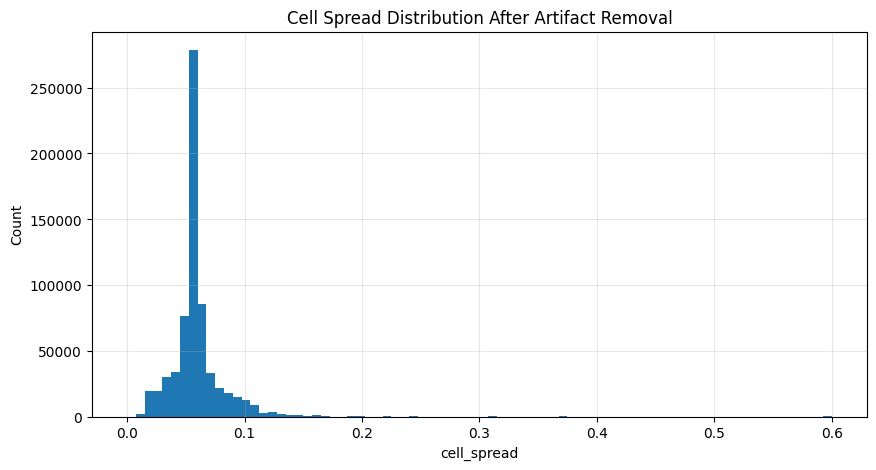

count    669389.000000
mean          0.059141
std           0.023759
min           0.000000
50%           0.057000
90%           0.083000
95%           0.099000
99%           0.134000
max           0.600000
Name: cell_spread, dtype: float64

In [10]:

plt.figure()
analysis_phys["cell_spread"].dropna().hist(bins=80)
plt.title("Cell Spread Distribution After Artifact Removal")
plt.xlabel("cell_spread")
plt.ylabel("Count")
plt.show()

analysis_phys["cell_spread"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])



## 8) Compare spread by SOC band and charge/discharge direction

This is one of the most important diagnostic tables in the notebook.

It answers:
- Is spread worse at low SOC?
- Is discharge worse than charge?
- Are there regimes that are naturally stressful for the excavator battery?

For an excavator, **discharge under working load** is more meaningful than passenger-EV cruising behavior.


In [11]:

regime_summary_clean = (
    analysis_phys.groupby(["soc_band", "current_direction"], observed=False)
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_temp_range=("temp_range", "mean"),
        p95_temp_range=("temp_range", lambda s: s.quantile(0.95)),
        mean_pack_v_std=("pack_v_std", "mean"),
        n=("cell_spread", "size"),
    )
)

regime_summary_clean


mean_spread  p95_spread  max_spread  mean_temp_range  p95_temp_range  mean_pack_v_std       n
soc_band current_direction                                                                                               
0-20     charge                0.052438       0.061       0.061         3.436326             5.0         0.009718     958
         discharge             0.072386       0.118       0.375         4.560280            10.0         0.010309    1999
20-40    charge                0.073314       0.092       0.111        10.733235            28.0         0.013012    2028
         discharge             0.071936       0.108       0.111         9.446246            30.0         0.013385    4995
40-60    charge                0.057945       0.110       0.133        14.129365            35.0         0.010068   14146
         discharge             0.067862       0.108       0.375         9.598586            29.0         0.012048   90667
60-80    charge                0.062987       0.098       0.127        11.291448            39.0         0.010548   25164
         discharge             0.061304       0.089       0.128         8.702534            28.0         0.011273  219252
80-100   charge                0.068568       0.148       0.600        10.957280            38.0         0.012934   67790
         discharge             0.052393       0.069       0.241        10.019808            30.0         0.009980  311293

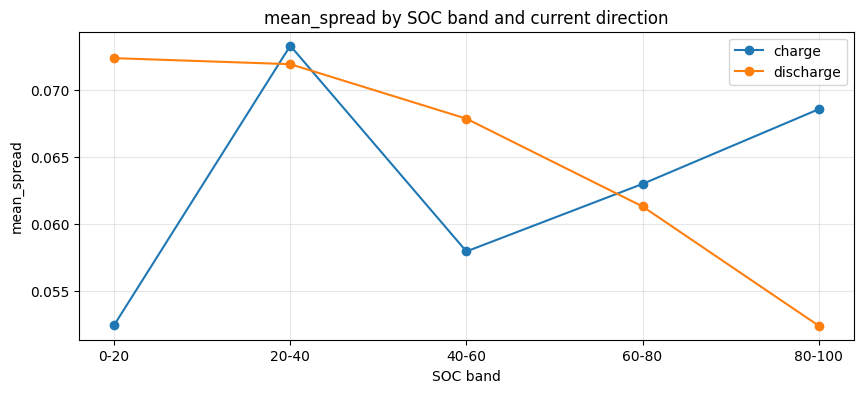

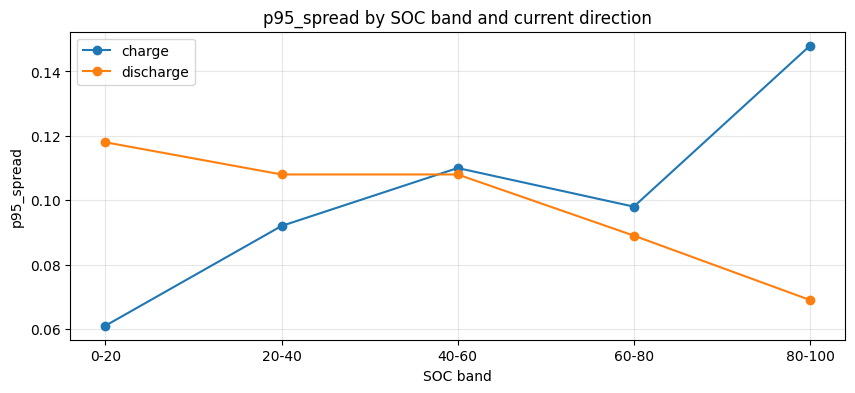

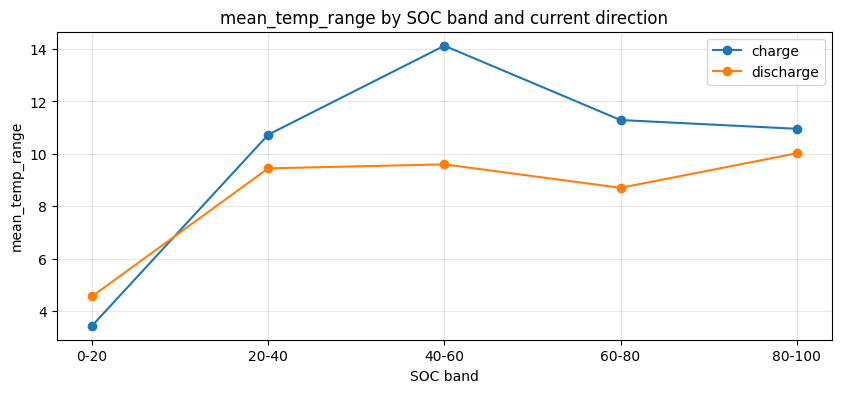

In [12]:

regime_plot = regime_summary_clean.reset_index()

for metric in ["mean_spread", "p95_spread", "mean_temp_range"]:
    plt.figure(figsize=(10, 4))
    for direction in ["charge", "discharge"]:
        x = regime_plot[regime_plot["current_direction"] == direction]
        plt.plot(x["soc_band"].astype(str), x[metric], marker="o", label=direction)
    plt.title(f"{metric} by SOC band and current direction")
    plt.xlabel("SOC band")
    plt.ylabel(metric)
    plt.legend()
    plt.show()



### Interpretation focus

At this point, leadership should notice:

- **low-SOC discharge** has the highest real spread behavior
- charge behavior is a separate regime and should not be mixed with heavy-duty work behavior
- thermal range is large in several regimes, which is expected in excavator duty cycles

The next question is:

> Is one module showing up as repeatedly hotter or weaker than the others?



## 9) Module frequency evidence — which module is hottest most often?

This section is the clearest way to show whether one module is consistently standing out.

Two views are used:
1. which module is reported as hottest most often
2. which module has the lowest mean voltage most often

If one module dominates both views, that is strong evidence of a local weakness.


In [13]:

print("Hottest module frequency (clean data)")
display(analysis_phys["hottest_module"].value_counts(dropna=False).sort_index())

print("Lowest-voltage module frequency (clean data)")
display(analysis_phys["lowest_voltage_module"].value_counts(dropna=False).sort_index())


Hottest module frequency (clean data)


hottest_module
1       467455
2        48071
3       145707
4        76722
5         5995
<NA>         1
Name: count, dtype: Int64

Lowest-voltage module frequency (clean data)


lowest_voltage_module
1       228403
2       119333
3       147739
4       112923
5       135549
<NA>         4
Name: count, dtype: Int64

In [14]:

module_summary_clean = []

for i in range(1, 6):
    module_summary_clean.append({
        "module": i,
        "mean_voltage_mean": analysis_phys[f"module_{i}_voltage_mean"].mean(),
        "mean_voltage_std": analysis_phys[f"module_{i}_voltage_std"].mean(),
        "mean_voltage_range": analysis_phys[f"module_{i}_voltage_range"].mean(),
        "mean_temp_mean": analysis_phys[f"module_{i}_temp_mean"].mean(),
        "mean_temp_range": analysis_phys[f"module_{i}_temp_range"].mean(),
        "times_lowest_voltage_module": (analysis_phys["lowest_voltage_module"] == i).sum(),
        "times_hottest_module": (analysis_phys["hottest_module"] == i).sum(),
    })

module_summary_clean = pd.DataFrame(module_summary_clean)

n_clean = len(analysis_phys)
module_rates = module_summary_clean.copy()
module_rates["pct_lowest_voltage_module"] = 100 * module_rates["times_lowest_voltage_module"] / n_clean
module_rates["pct_hottest_module"] = 100 * module_rates["times_hottest_module"] / n_clean

module_rates[[
    "module", "pct_lowest_voltage_module", "pct_hottest_module",
    "mean_voltage_mean", "mean_temp_mean", "mean_temp_range"
]]


,module,pct_lowest_voltage_module,pct_hottest_module,mean_voltage_mean,mean_temp_mean,mean_temp_range
0,1,30.701350,62.834111,3.319976,32.702898,8.091847
1,2,16.040438,6.461581,3.320418,32.175663,8.766971
2,3,19.858700,19.585564,3.320338,32.453959,7.346813
3,4,15.178822,10.312776,3.320443,32.292307,7.357535
4,5,18.220152,0.805833,3.320415,31.861642,7.206307


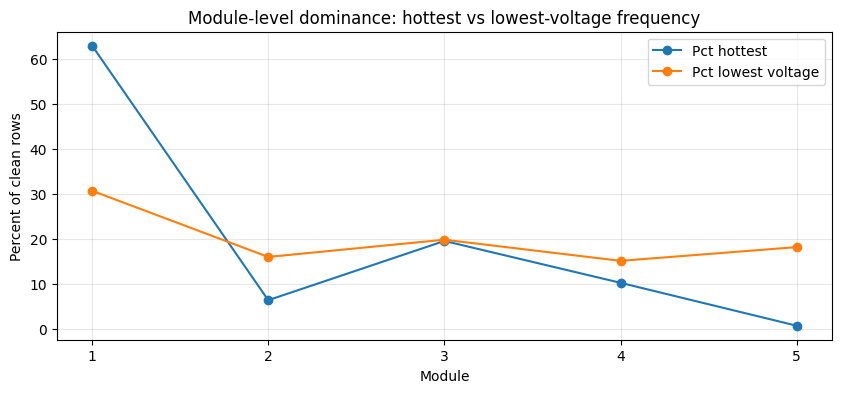

In [15]:

plt.figure(figsize=(10, 4))
plt.plot(module_rates["module"], module_rates["pct_hottest_module"], marker="o", label="Pct hottest")
plt.plot(module_rates["module"], module_rates["pct_lowest_voltage_module"], marker="o", label="Pct lowest voltage")
plt.title("Module-level dominance: hottest vs lowest-voltage frequency")
plt.xlabel("Module")
plt.ylabel("Percent of clean rows")
plt.xticks(module_rates["module"])
plt.legend()
plt.show()



### Founder-level takeaway from this section

If Module 1 is:
- hottest much more often than the others
- lowest-voltage more often than the others
- slightly lower mean voltage
- slightly higher mean temperature

then we are no longer looking at random variation.

We are looking at a **persistently stressed or weaker local region of the pack**.



## 10) How Module 1 behaves across SOC bands

This checks whether Module 1 dominance is:
- only visible in one narrow corner of operation
- or persistent across the operating envelope

That distinction matters:
- **narrow-only** would suggest a regime-specific effect
- **persistent across bands** suggests structural thermal/electrical bias


In [16]:

module1_soc = (
    analysis_phys.assign(
        mod1_hot=analysis_phys["hottest_module"] == 1,
        mod1_low=analysis_phys["lowest_voltage_module"] == 1
    )
    .groupby("soc_band", observed=False)
    .agg(
        pct_hot_mod1=("mod1_hot", "mean"),
        pct_low_mod1=("mod1_low", "mean"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
)

module1_soc["pct_hot_mod1"] *= 100
module1_soc["pct_low_mod1"] *= 100
module1_soc


,pct_hot_mod1,pct_low_mod1,mean_spread,p95_spread,mean_temp_range,n
soc_band,,,,,,
0-20,31.349341,40.987487,0.065912,0.106,4.196145,2957
20-40,54.022498,31.942467,0.072336,0.107,9.817884,7023
40-60,63.659088,26.999513,0.066605,0.109,10.210079,104813
60-80,63.927484,31.781601,0.061474,0.091,8.969077,244416
80-100,62.679941,31.049137,0.055129,0.091,10.187452,379083


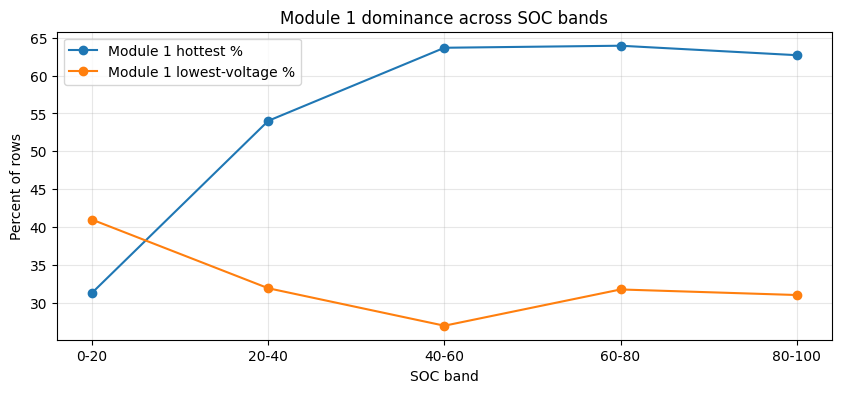

In [17]:

plt.figure(figsize=(10, 4))
plt.plot(module1_soc.index.astype(str), module1_soc["pct_hot_mod1"], marker="o", label="Module 1 hottest %")
plt.plot(module1_soc.index.astype(str), module1_soc["pct_low_mod1"], marker="o", label="Module 1 lowest-voltage %")
plt.title("Module 1 dominance across SOC bands")
plt.xlabel("SOC band")
plt.ylabel("Percent of rows")
plt.legend()
plt.show()



## 11) Define excavator working-load conditions

This notebook treats **working load** as high current in the top 30% of the clean dataset.

Why this matters:
- excavator stress is best revealed during active-duty electrical load
- low-speed or stationary operation can still be high electrical stress
- this is more meaningful than passenger-EV assumptions

We compute a threshold and isolate that slice.


In [18]:

work_current_thr = analysis_phys["abs_current"].quantile(0.70)
high_current_thr = analysis_phys["abs_current"].quantile(0.90)

working_load = analysis_phys[
    (analysis_phys["current_direction"] == "discharge") &
    (analysis_phys["abs_current"] >= work_current_thr)
].copy()

print("Working-load threshold:", work_current_thr)
print("High-current threshold:", high_current_thr)
print("Working-load rows:", len(working_load))

working_load[[
    "soc", "abs_current", "cell_spread", "temp_range", "hottest_module", "lowest_voltage_module"
]].describe()


Working-load threshold: 61.0
High-current threshold: 113.0
Working-load rows: 228996


,soc,abs_current,cell_spread,temp_range,hottest_module,lowest_voltage_module
count,228993.000000,228996.000000,215138.000000,228996.000000,228996.0,228996.0
mean,77.919246,100.127453,0.057396,10.548870,1.603936,2.741672
std,16.800796,31.138907,0.017118,8.498086,1.007202,1.463586
min,0.000000,61.000000,0.010000,1.000000,1.0,1.0
25%,67.000000,75.000000,0.052000,6.000000,1.0,1.0
50%,81.000000,91.000000,0.057000,9.000000,1.0,3.0
75%,92.000000,126.000000,0.062000,12.000000,2.0,4.0
max,100.000000,1451.000000,0.375000,117.000000,5.0,5.0



## 12) Working-load module comparison

This is one of the strongest sections in the notebook.

It asks:

> Under genuine excavator work conditions, which module is hottest most often, and which module is lowest-voltage most often?

If Module 1 dominates here as well, that makes the case much stronger.


In [19]:

working_module_summary = []

for i in range(1, 6):
    x = working_load.copy()
    working_module_summary.append({
        "module": i,
        "pct_hottest": 100 * (x["hottest_module"] == i).mean(),
        "pct_lowest_voltage": 100 * (x["lowest_voltage_module"] == i).mean(),
        "mean_voltage_mean": x[f"module_{i}_voltage_mean"].mean(),
        "mean_voltage_range": x[f"module_{i}_voltage_range"].mean(),
        "mean_temp_mean": x[f"module_{i}_temp_mean"].mean(),
        "mean_temp_range": x[f"module_{i}_temp_range"].mean(),
    })

working_module_summary = pd.DataFrame(working_module_summary).sort_values("pct_hottest", ascending=False)
working_module_summary


,module,pct_hottest,pct_lowest_voltage,mean_voltage_mean,mean_voltage_range,mean_temp_mean,mean_temp_range
0,1,71.163688,29.906199,3.340214,0.059016,33.540295,8.911902
2,3,18.328268,21.526140,3.340639,0.050334,33.281780,8.072604
3,4,6.023686,14.929518,3.340804,0.050526,33.083698,8.080097
1,2,4.090464,16.075390,3.340674,0.050412,32.923236,9.610731
4,5,0.393893,17.562752,3.340783,0.050074,32.584539,7.930462


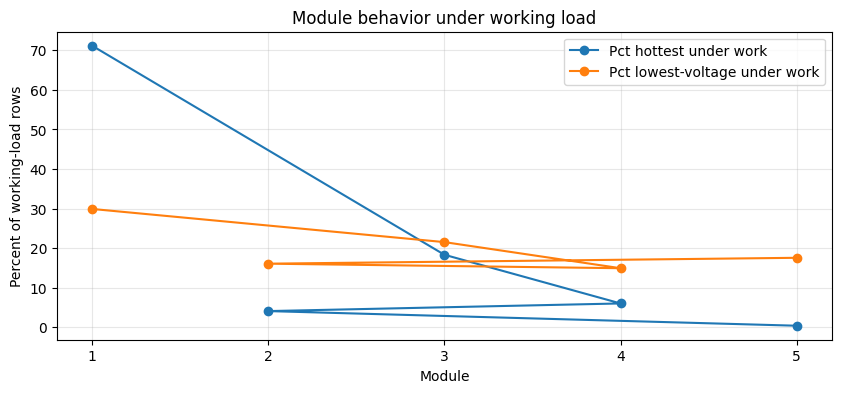

In [20]:

plt.figure(figsize=(10, 4))
plt.plot(working_module_summary["module"], working_module_summary["pct_hottest"], marker="o", label="Pct hottest under work")
plt.plot(working_module_summary["module"], working_module_summary["pct_lowest_voltage"], marker="o", label="Pct lowest-voltage under work")
plt.title("Module behavior under working load")
plt.xlabel("Module")
plt.ylabel("Percent of working-load rows")
plt.xticks(working_module_summary["module"])
plt.legend()
plt.show()



### Why this matters

A founder should interpret this as:

- Module 1 is not just “warm sometimes”
- it is disproportionately involved in **real work-state stress**
- that points toward either:
  - cooling/layout imbalance
  - local resistance increase
  - or both



## 13) Low-SOC + working-load slice — the key stress condition

This is the most important physical stress test in the notebook.

Why:
- low SOC exposes weak cells more clearly
- discharge under load increases voltage sag
- excavator work can sustain high electrical demand

So this slice is where a weak module should reveal itself most clearly.


In [21]:

low_soc_work = working_load[working_load["soc"] <= 20].copy()

print("Low-SOC working rows:", len(low_soc_work))

print("Grouped by lowest-voltage module")
display(
    low_soc_work.groupby("lowest_voltage_module")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values("mean_spread", ascending=False)
)

print("Grouped by hottest module")
display(
    low_soc_work.groupby("hottest_module")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values("mean_spread", ascending=False)
)


Low-SOC working rows: 1766
Grouped by lowest-voltage module


,mean_spread,p95_spread,mean_temp_range,n
lowest_voltage_module,,,,
1,0.092531,0.149,6.819495,831
3,0.056435,0.063,2.230137,365
2,0.055825,0.063,2.232456,228
4,0.055572,0.063,2.402062,194
5,0.055257,0.063,2.533784,148


Grouped by hottest module


,mean_spread,p95_spread,mean_temp_range,n
hottest_module,,,,
1,0.091712,0.149,6.727711,830
2,0.056990,0.063,2.348328,867
5,0.055000,0.063,3.262295,61
3,0.051250,0.053,1.500000,4
4,0.051000,0.054,1.500000,4



### Diagnostic interpretation

This section should make the point visually and numerically:

If Module 1 is the hottest or lowest-voltage module in the **low-SOC working slice**, and spread jumps significantly compared with other modules, then Module 1 is the most convincing candidate for true underperformance.



## 14) Scatter plots leadership can understand

These two plots make the story intuitive:

1. **Cell Spread vs SOC under Working Load**  
   Shows where spread becomes more severe under real working conditions.

2. **Cell Spread vs Current at Low SOC (Discharge)**  
   Shows what happens when the machine is both low on charge and pulling load.


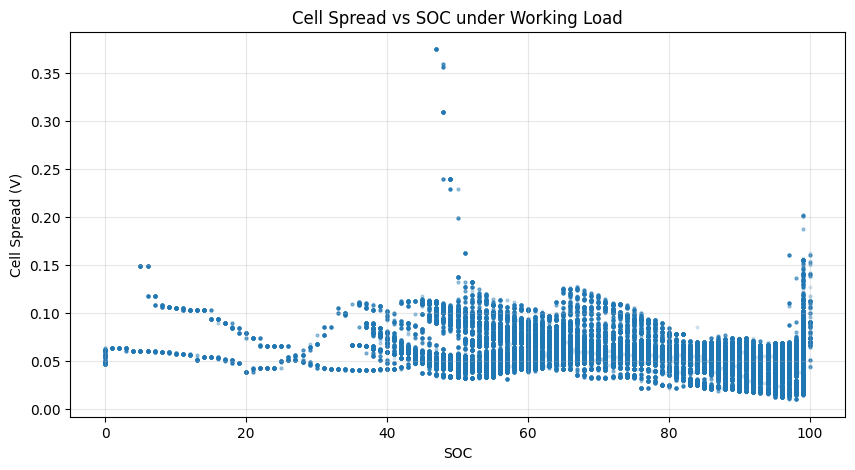

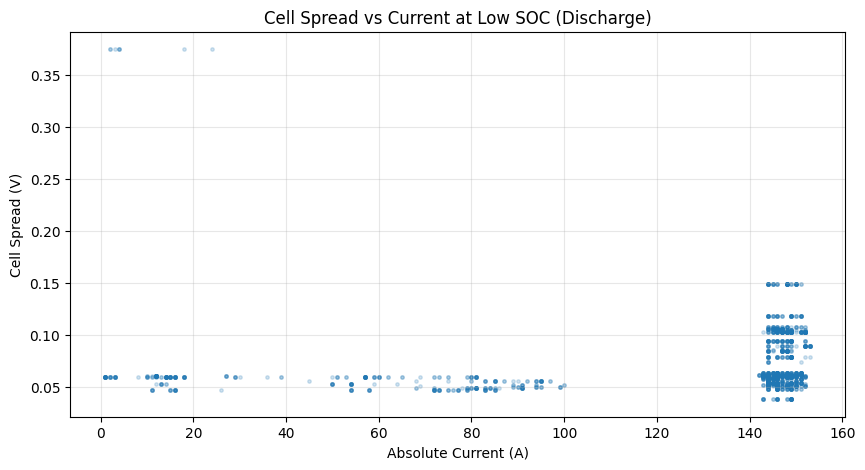

,abs_current,cell_spread,temp_range,pack_v_std
count,1999.000000,1944.000000,1999.000000,1999.000000
mean,126.969985,0.072386,4.560280,0.010309
std,42.522020,0.031326,2.994196,0.002847
min,1.000000,0.038000,1.000000,0.005055
25%,144.000000,0.054000,2.000000,0.009010
50%,146.000000,0.060000,4.000000,0.010084
75%,148.000000,0.089000,7.000000,0.011437
max,153.000000,0.375000,12.000000,0.041258


In [22]:

plt.figure(figsize=(10, 5))
plt.scatter(
    working_load["soc"],
    working_load["cell_spread"],
    s=4,
    alpha=0.15
)
plt.title("Cell Spread vs SOC under Working Load")
plt.xlabel("SOC")
plt.ylabel("Cell Spread (V)")
plt.show()

plt.figure(figsize=(10, 5))
low_soc_discharge = analysis_phys[
    (analysis_phys["soc"] <= 20) &
    (analysis_phys["current_direction"] == "discharge")
].copy()

plt.scatter(
    low_soc_discharge["abs_current"],
    low_soc_discharge["cell_spread"],
    s=6,
    alpha=0.2
)
plt.title("Cell Spread vs Current at Low SOC (Discharge)")
plt.xlabel("Absolute Current (A)")
plt.ylabel("Cell Spread (V)")
plt.show()

low_soc_discharge[["abs_current", "cell_spread", "temp_range", "pack_v_std"]].describe()



## 15) Separate balancing-like charge behavior from real under-load weakness

This is important for credibility.

Some elevated spread happens during:
- charging
- very low current
- balancing / resting windows

That should **not** be confused with genuine under-load electrical weakness.

So we explicitly separate balancing-like windows.


In [23]:

analysis_phys["is_balancing_like"] = (
    (analysis_phys["current_direction"] == "charge") &
    (analysis_phys["abs_current"] <= 2)
)

balancing_summary = analysis_phys.groupby("is_balancing_like").agg(
    mean_spread=("cell_spread", "mean"),
    p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
    max_spread=("cell_spread", "max"),
    mean_temp_range=("temp_range", "mean"),
    mean_pack_v_std=("pack_v_std", "mean"),
    n=("cell_spread", "size"),
)

balancing_summary


,mean_spread,p95_spread,max_spread,mean_temp_range,mean_pack_v_std,n
is_balancing_like,,,,,,
False,0.058081,0.092,0.6,9.453666,0.010808,635910
True,0.065562,0.129,0.6,11.435363,0.011882,108041


In [24]:

balancing_trips = (
    analysis_phys[analysis_phys["is_balancing_like"]]
    .groupby("trip")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_temp_range=("temp_range", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values(["mean_spread", "p95_spread"], ascending=False)
)

balancing_trips.head(20)


,mean_spread,p95_spread,max_spread,mean_temp_range,n
trip,,,,,
EV01_000903,0.174493,0.1960,0.196,8.521739,69
EV01_000851,0.160720,0.1870,0.187,40.271186,118
EV01_000895,0.160547,0.1770,0.177,16.915423,201
EV01_001265,0.147354,0.1540,0.155,13.803954,607
EV01_001266,0.146273,0.1590,0.159,11.724252,903
EV01_000988,0.135862,0.6000,0.600,7.355384,2721
EV01_001082,0.135000,0.1350,0.135,1.000000,8
EV01_001179,0.130231,0.1400,0.140,13.469274,179
EV01_001178,0.128568,0.1650,0.166,15.094094,999



### Practical interpretation

Founder takeaway:
- yes, charge/balancing windows can show elevated spread
- but that is a **different phenomenon** from a weak module under work load
- this notebook keeps those two behaviors separated



## 16) Daily evidence — is Module 1 persistent over time?

If Module 1 were only problematic for one day, the issue might be temporary.

This section checks persistence by day:
- percentage of rows where Module 1 is hottest
- percentage of rows where Module 1 is lowest-voltage
- daily spread and daily current context


In [25]:

daily_mod1 = (
    analysis_phys.assign(
        mod1_hot=analysis_phys["hottest_module"] == 1,
        mod1_low=analysis_phys["lowest_voltage_module"] == 1
    )
    .groupby("date")
    .agg(
        pct_mod1_hot=("mod1_hot", "mean"),
        pct_mod1_low=("mod1_low", "mean"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        mean_abs_current=("abs_current", "mean"),
        n=("cell_spread", "size"),
    )
)

daily_mod1["pct_mod1_hot"] *= 100
daily_mod1["pct_mod1_low"] *= 100

display(daily_mod1.sort_values("pct_mod1_low", ascending=False).head(15))


,pct_mod1_hot,pct_mod1_low,mean_spread,p95_spread,mean_temp_range,mean_abs_current,n
date,,,,,,,
2026-02-24,100.0,100.0,0.069867,0.089,3.123288,10.823256,219
2026-01-28,41.733481,89.894941,0.059049,0.061,13.166851,9.342142,7234
2026-02-02,99.960808,88.869491,0.046664,0.058,5.764207,32.885338,28067
2026-01-29,72.73217,81.178625,0.054564,0.102,7.233301,41.167983,18564
2026-01-31,99.891605,73.455378,0.052502,0.111,7.812357,69.090585,8303
2026-01-23,99.95539,60.981413,0.036893,0.058,35.072565,42.025713,13450
2026-02-08,62.421769,60.0,0.065198,0.140,4.439728,67.072035,3675
2026-02-01,88.321246,58.839645,0.046737,0.064,6.528606,43.844231,18615
2026-01-27,99.992657,58.650316,0.059848,0.103,34.973052,39.385328,13619


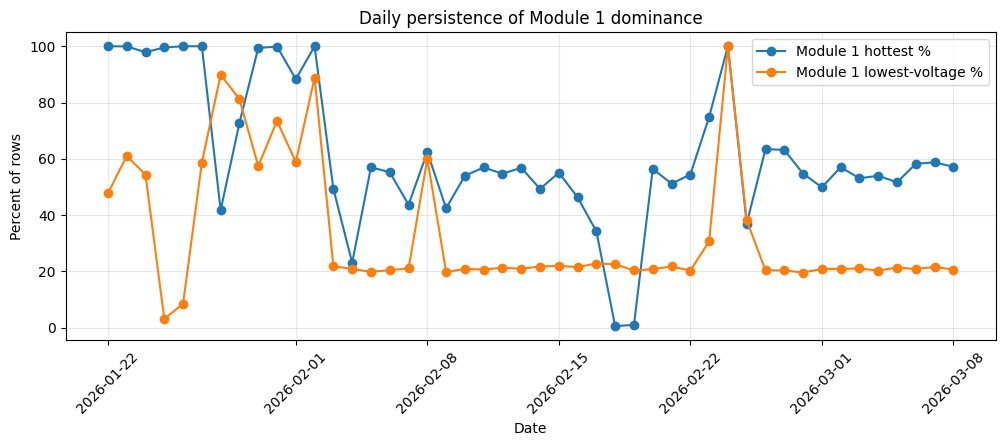

In [26]:

plt.figure(figsize=(12, 4))
plt.plot(daily_mod1.index, daily_mod1["pct_mod1_hot"], marker="o", label="Module 1 hottest %")
plt.plot(daily_mod1.index, daily_mod1["pct_mod1_low"], marker="o", label="Module 1 lowest-voltage %")
plt.title("Daily persistence of Module 1 dominance")
plt.xlabel("Date")
plt.ylabel("Percent of rows")
plt.xticks(rotation=45)
plt.legend()
plt.show()



## 17) Trip-level evidence for engineering review

This section ranks trips by:
- spread severity
- temperature context
- current context
- Module 1 persistence

This is useful for:
- review with engineering
- waveform drill-down later
- selecting trips for root-cause deep dive


In [27]:

trip_features = (
    analysis_phys.assign(
        mod1_hot=analysis_phys["hottest_module"] == 1,
        mod1_low=analysis_phys["lowest_voltage_module"] == 1,
        low_soc=(analysis_phys["soc"] <= 20),
        high_load=(analysis_phys["abs_current"] >= work_current_thr),
        discharge=(analysis_phys["current_direction"] == "discharge")
    )
    .groupby("trip")
    .agg(
        n=("cell_spread", "size"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        max_spread=("cell_spread", "max"),
        mean_temp_range=("temp_range", "mean"),
        p95_temp_range=("temp_range", lambda s: s.quantile(0.95)),
        mean_abs_current=("abs_current", "mean"),
        pct_low_soc=("low_soc", "mean"),
        pct_high_load=("high_load", "mean"),
        pct_discharge=("discharge", "mean"),
        pct_mod1_hot=("mod1_hot", "mean"),
        pct_mod1_low=("mod1_low", "mean"),
    )
)

for col in ["pct_low_soc", "pct_high_load", "pct_discharge", "pct_mod1_hot", "pct_mod1_low"]:
    trip_features[col] *= 100

trip_features.sort_values(
    ["p95_spread", "pct_mod1_low", "pct_mod1_hot"],
    ascending=False
).head(25)


,n,mean_spread,p95_spread,max_spread,mean_temp_range,p95_temp_range,mean_abs_current,pct_low_soc,pct_high_load,pct_discharge,pct_mod1_hot,pct_mod1_low
trip,,,,,,,,,,,,
EV01_000988,4464,0.122678,0.600,0.600,7.755824,11.0,14.073387,0.000000,10.304659,22.379032,64.202509,22.446237
EV01_000894,4149,0.123427,0.240,0.375,2.937816,4.0,35.325217,0.192818,25.162690,99.879489,100.0,82.164377
EV01_000903,591,0.096297,0.170,0.196,8.213198,9.0,41.707192,0.000000,28.595601,87.140440,100.0,99.153976
EV01_001178,8794,0.088621,0.163,0.166,12.637025,17.0,42.307246,0.000000,29.360928,88.605868,63.566068,21.480555
EV01_001266,1420,0.135447,0.159,0.159,11.500704,12.0,1.838505,0.000000,0.000000,36.267606,64.859155,24.225352
EV01_001265,1807,0.086797,0.153,0.155,15.219701,17.0,52.209740,0.000000,51.245158,66.408412,68.622025,19.092418
EV01_001262,3236,0.069933,0.148,0.150,10.989802,12.0,80.817028,0.000000,66.069221,85.228677,88.133498,19.406675
EV01_001181,7618,0.077252,0.140,0.164,6.821869,8.0,34.135259,0.000000,22.985035,83.079548,63.914413,21.265424
EV01_001080,2153,0.069755,0.135,0.201,6.173711,7.0,23.923974,0.000000,28.750581,70.692058,47.979563,99.814213



## 18) Optional candidate event labels (pre-score stage)

We are **not** creating the final production underperformance score yet.

But this cell creates interpretable candidate labels so leadership can see how future monitoring might work:

- `under_load_electrical_stress`
- `severe_under_load_stress`
- `module1_suspect_event`
- `balancing_spread_event`

These are not the final model outputs.  
They are transparent diagnostic labels.


In [28]:

spread_p95 = analysis_phys["cell_spread"].quantile(0.95)
spread_p99 = analysis_phys["cell_spread"].quantile(0.99)
temp_p95 = analysis_phys["temp_range"].quantile(0.95)
packstd_p95 = analysis_phys["pack_v_std"].quantile(0.95)

labeled = analysis_phys.copy()

labeled["is_low_soc"] = labeled["soc"] <= 20
labeled["is_high_current"] = labeled["abs_current"] >= high_current_thr
labeled["is_working_load"] = labeled["abs_current"] >= work_current_thr
labeled["is_discharge"] = labeled["current_direction"] == "discharge"
labeled["is_charge"] = labeled["current_direction"] == "charge"

labeled["mod1_hot"] = labeled["hottest_module"] == 1
labeled["mod1_low"] = labeled["lowest_voltage_module"] == 1

labeled["high_spread"] = labeled["cell_spread"] >= spread_p95
labeled["very_high_spread"] = labeled["cell_spread"] >= spread_p99
labeled["high_temp_range"] = labeled["temp_range"] >= temp_p95
labeled["high_pack_std"] = labeled["pack_v_std"] >= packstd_p95

labeled["under_load_electrical_stress"] = (
    labeled["is_discharge"] &
    labeled["is_working_load"] &
    labeled["high_spread"]
)

labeled["severe_under_load_stress"] = (
    labeled["is_discharge"] &
    labeled["is_high_current"] &
    labeled["high_spread"] &
    (labeled["is_low_soc"] | labeled["mod1_low"] | labeled["mod1_hot"])
)

labeled["module1_suspect_event"] = (
    labeled["mod1_hot"] &
    labeled["mod1_low"] &
    labeled["high_spread"]
)

labeled["balancing_spread_event"] = (
    labeled["is_charge"] &
    (labeled["abs_current"] <= 2) &
    labeled["high_spread"]
)

event_summary = pd.DataFrame({
    "count": [
        labeled["under_load_electrical_stress"].sum(),
        labeled["severe_under_load_stress"].sum(),
        labeled["module1_suspect_event"].sum(),
        labeled["balancing_spread_event"].sum(),
    ],
    "pct_of_rows": [
        labeled["under_load_electrical_stress"].mean() * 100,
        labeled["severe_under_load_stress"].mean() * 100,
        labeled["module1_suspect_event"].mean() * 100,
        labeled["balancing_spread_event"].mean() * 100,
    ]
}, index=[
    "under_load_electrical_stress",
    "severe_under_load_stress",
    "module1_suspect_event",
    "balancing_spread_event",
])

event_summary


,count,pct_of_rows
under_load_electrical_stress,6340,0.852207
severe_under_load_stress,2444,0.328516
module1_suspect_event,11154,1.499292
balancing_spread_event,14758,1.983733


In [29]:

soc_event_rates = (
    labeled.groupby("soc_band", observed=False)
    .agg(
        under_load_electrical_stress=("under_load_electrical_stress", "mean"),
        severe_under_load_stress=("severe_under_load_stress", "mean"),
        module1_suspect_event=("module1_suspect_event", "mean"),
        balancing_spread_event=("balancing_spread_event", "mean"),
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        n=("cell_spread", "size"),
    )
)

for c in [
    "under_load_electrical_stress",
    "severe_under_load_stress",
    "module1_suspect_event",
    "balancing_spread_event",
]:
    soc_event_rates[c] *= 100

soc_event_rates


,under_load_electrical_stress,severe_under_load_stress,module1_suspect_event,balancing_spread_event,mean_spread,p95_spread,n
soc_band,,,,,,,
0-20,13.527224,13.527224,13.797768,0.000000,0.065912,0.106,2957
20-40,4.029617,0.740424,0.868575,1.281504,0.072336,0.107,7023
40-60,3.178041,1.197371,5.255073,2.037915,0.066605,0.109,104813
60-80,0.667305,0.299489,0.361678,0.415276,0.061474,0.091,244416
80-100,0.183337,0.001319,1.13247,3.038121,0.055129,0.091,379083


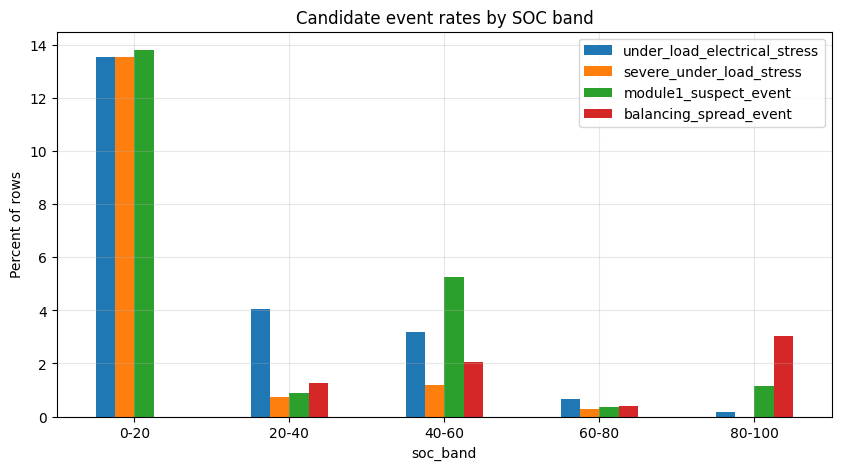

In [30]:

plot_df = soc_event_rates[
    [
        "under_load_electrical_stress",
        "severe_under_load_stress",
        "module1_suspect_event",
        "balancing_spread_event",
    ]
].copy()

plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Candidate event rates by SOC band")
plt.ylabel("Percent of rows")
plt.xticks(rotation=0)
plt.show()



## 19) Executive conclusion

### What is now clear

1. **The raw 3.3 V spread spikes were artifacts**, not real pack failures.  
   Those were removed before drawing conclusions.

2. **Module 1 is the strongest persistent suspect**.  
   It is disproportionately:
   - the hottest module
   - the lowest-voltage module
   - slightly lower in mean voltage
   - slightly higher in mean temperature

3. **The clearest real stress condition is low SOC + discharge + high load**.  
   That is where spread rises the most in a physically believable way.

4. **Balancing-like charging windows also show spread**, but that is a separate phenomenon and should not be confused with true under-load weakness.

5. The evidence so far suggests:
   - a likely **Module 1 thermal/electrical bias**
   - visible under real excavator duty conditions
   - strong enough to justify targeted engineering review

---

## Recommended next step after this notebook

Use this notebook as the founder-facing diagnostic review, then move to:
- a formal underperformance score
- trip-level ranking for maintenance review
- engineering inspection focused on Module 1 cooling path / wiring / internal resistance behavior


In [31]:
print("Unique module_1_lowest_cell values:")
display(
    analysis_phys["module_1_lowest_cell"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nUnique module_1_hottest_sensor values:")
display(
    analysis_phys["module_1_hottest_sensor"]
    .value_counts(dropna=False)
    .sort_index()
)

Unique module_1_lowest_cell values:


module_1_lowest_cell
M1_C1       1403
M1_C10        14
M1_C11         7
M1_C12         6
M1_C13       228
M1_C14        44
M1_C15       225
M1_C16         3
M1_C17       276
M1_C18        99
M1_C19       197
M1_C21        62
M1_C22        12
M1_C23       437
M1_C24        42
M1_C25    732120
M1_C26      6959
M1_C29       211
M1_C30        18
M1_C31        45
M1_C32       196
M1_C33        43
M1_C34       340
M1_C35         1
M1_C36         3
M1_C5        348
M1_C6        238
M1_C7         61
M1_C8         19
M1_C9        289
None           5
Name: count, dtype: int64


Unique module_1_hottest_sensor values:


module_1_hottest_sensor
M1_T1     254208
M1_T10      9815
M1_T11       781
M1_T12        32
M1_T13       783
M1_T14      1310
M1_T15      1142
M1_T16        29
M1_T17       130
M1_T18     59155
M1_T2       3133
M1_T3       1638
M1_T4      32486
M1_T5       5585
M1_T6      54607
M1_T7      99231
M1_T8     217201
M1_T9       2681
None           4
Name: count, dtype: int64

In [32]:
mod1_cell_overall = (
    analysis_phys["module_1_lowest_cell"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .rename("pct_rows")
    .reset_index()
)

mod1_cell_overall.columns = ["module_1_lowest_cell", "pct_rows"]

display(mod1_cell_overall)

,module_1_lowest_cell,pct_rows
0,M1_C25,98.409707
1,M1_C26,0.935411
2,M1_C1,0.188588
3,M1_C23,0.058740
4,M1_C5,0.046777
5,M1_C34,0.045702
6,M1_C9,0.038847
7,M1_C17,0.037099
8,M1_C6,0.031991
9,M1_C13,0.030647


In [33]:
mod1_active = analysis_phys[analysis_phys["lowest_voltage_module"] == 1].copy()

print("Rows where Module 1 is the lowest-voltage module:", len(mod1_active))

mod1_cell_when_mod1_low = (
    mod1_active["module_1_lowest_cell"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct_when_module1_is_lowest_module")
    .reset_index()
)

mod1_cell_when_mod1_low.columns = ["module_1_lowest_cell", "pct_when_module1_is_lowest_module"]

display(mod1_cell_when_mod1_low)

Rows where Module 1 is the lowest-voltage module: 228403


,module_1_lowest_cell,pct_when_module1_is_lowest_module
0,M1_C25,98.583206
1,M1_C26,1.010932
2,M1_C1,0.148860
3,M1_C17,0.043782
4,M1_C23,0.029772
5,M1_C5,0.023205
6,M1_C32,0.018826
7,M1_C18,0.017513
8,M1_C13,0.015762
9,M1_C34,0.014886


In [34]:
mod1_stress = analysis_phys[
    (analysis_phys["lowest_voltage_module"] == 1) &
    (analysis_phys["soc"] <= 20) &
    (analysis_phys["current_direction"] == "discharge") &
    (analysis_phys["abs_current"] >= work_current_thr)
].copy()

print("Stress rows for Module 1:", len(mod1_stress))

mod1_cell_stress = (
    mod1_stress["module_1_lowest_cell"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct_under_lowSOC_discharge_workload")
    .reset_index()
)

mod1_cell_stress.columns = ["module_1_lowest_cell", "pct_under_lowSOC_discharge_workload"]

display(mod1_cell_stress)

Stress rows for Module 1: 831


,module_1_lowest_cell,pct_under_lowSOC_discharge_workload
0,M1_C25,99.037304
1,M1_C26,0.962696


In [35]:
mod1_cell_compare = (
    mod1_cell_overall
    .merge(mod1_cell_when_mod1_low, on="module_1_lowest_cell", how="outer")
    .merge(mod1_cell_stress, on="module_1_lowest_cell", how="outer")
    .fillna(0)
    .sort_values("pct_under_lowSOC_discharge_workload", ascending=False)
)

display(mod1_cell_compare)

,module_1_lowest_cell,pct_rows,pct_when_module1_is_lowest_module,pct_under_lowSOC_discharge_workload
15,M1_C25,98.409707,98.583206,99.037304
16,M1_C26,0.935411,1.010932,0.962696
29,M1_C9,0.038847,0.007881,0.000000
28,M1_C8,0.002554,0.001313,0.000000
27,M1_C7,0.008199,0.005254,0.000000
26,M1_C6,0.031991,0.014010,0.000000
25,M1_C5,0.046777,0.023205,0.000000
24,M1_C36,0.000403,0.000000,0.000000
23,M1_C35,0.000134,0.000000,0.000000
22,M1_C34,0.045702,0.014886,0.000000


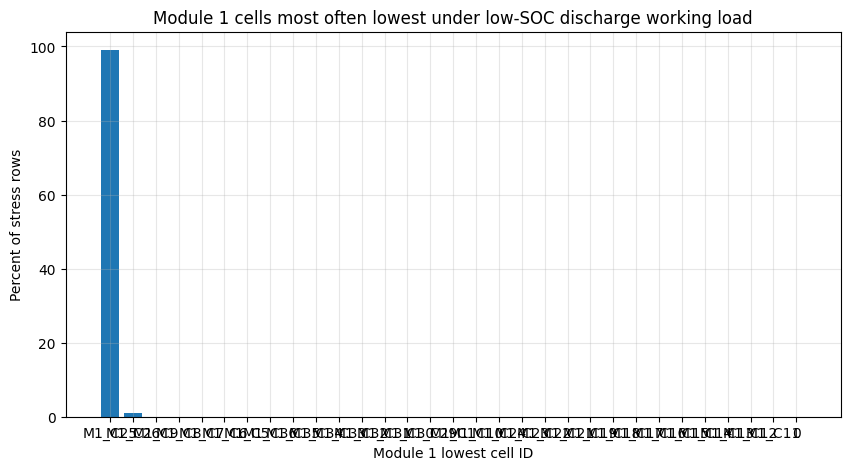

In [36]:
plt.figure(figsize=(10, 5))
plt.bar(
    mod1_cell_compare["module_1_lowest_cell"].astype(str),
    mod1_cell_compare["pct_under_lowSOC_discharge_workload"]
)
plt.title("Module 1 cells most often lowest under low-SOC discharge working load")
plt.xlabel("Module 1 lowest cell ID")
plt.ylabel("Percent of stress rows")
plt.show()

In [37]:
mod1_cell_severity = (
    mod1_active.groupby("module_1_lowest_cell")
    .agg(
        mean_spread=("cell_spread", "mean"),
        p95_spread=("cell_spread", lambda s: s.quantile(0.95)),
        mean_temp_range=("temp_range", "mean"),
        mean_abs_current=("abs_current", "mean"),
        mean_soc=("soc", "mean"),
        n=("cell_spread", "size"),
    )
    .sort_values(["mean_spread", "p95_spread"], ascending=False)
)

display(mod1_cell_severity)

,mean_spread,p95_spread,mean_temp_range,mean_abs_current,mean_soc,n
module_1_lowest_cell,,,,,,
M1_C26,0.062397,0.13000,6.208748,42.951040,86.119965,2309
M1_C25,0.058753,0.10300,11.278424,40.814739,78.775638,225167
M1_C30,0.046111,0.06200,4.777778,25.555556,99.000000,9
M1_C7,0.041636,0.06150,7.333333,39.090909,99.000000,12
M1_C21,0.035250,0.07405,14.000000,93.812500,73.125000,8
M1_C1,0.031921,0.08900,8.341176,31.474242,93.461765,340
M1_C14,0.028833,0.03400,19.000000,19.166667,88.333333,6
M1_C17,0.027136,0.04500,7.930000,30.950000,96.010000,100
M1_C34,0.026667,0.03600,14.470588,36.469697,86.294118,34


In [38]:
daily_mod1_cell = (
    mod1_active.groupby(["date", "module_1_lowest_cell"])
    .size()
    .rename("n")
    .reset_index()
)

daily_totals = (
    mod1_active.groupby("date")
    .size()
    .rename("day_total")
    .reset_index()
)

daily_mod1_cell = daily_mod1_cell.merge(daily_totals, on="date", how="left")
daily_mod1_cell["pct_of_mod1_low_rows_that_day"] = 100 * daily_mod1_cell["n"] / daily_mod1_cell["day_total"]

display(
    daily_mod1_cell.sort_values(
        ["pct_of_mod1_low_rows_that_day", "n"],
        ascending=False
    ).head(20)
)

,date,module_1_lowest_cell,n,day_total,pct_of_mod1_low_rows_that_day
213,2026-02-22,M1_C25,2479,2479,100.000000
201,2026-02-16,M1_C25,1280,1280,100.000000
206,2026-02-18,M1_C25,147,147,100.000000
102,2026-02-04,M1_C25,141,141,100.000000
14,2026-01-25,M1_C25,7,7,100.000000
85,2026-02-02,M1_C25,24940,24943,99.987973
223,2026-02-26,M1_C25,4714,4715,99.978791
199,2026-02-15,M1_C25,3471,3472,99.971198
247,2026-03-08,M1_C25,5463,5466,99.945115
211,2026-02-21,M1_C25,3045,3047,99.934362


In [39]:
daily_mod1_cell = (
    mod1_active.groupby(["date", "module_1_lowest_cell"])
    .size()
    .rename("n")
    .reset_index()
)

daily_totals = (
    mod1_active.groupby("date")
    .size()
    .rename("day_total")
    .reset_index()
)

daily_mod1_cell = daily_mod1_cell.merge(daily_totals, on="date", how="left")
daily_mod1_cell["pct_of_mod1_low_rows_that_day"] = 100 * daily_mod1_cell["n"] / daily_mod1_cell["day_total"]

display(
    daily_mod1_cell.sort_values(
        ["pct_of_mod1_low_rows_that_day", "n"],
        ascending=False
    ).head(20)
)

,date,module_1_lowest_cell,n,day_total,pct_of_mod1_low_rows_that_day
213,2026-02-22,M1_C25,2479,2479,100.000000
201,2026-02-16,M1_C25,1280,1280,100.000000
206,2026-02-18,M1_C25,147,147,100.000000
102,2026-02-04,M1_C25,141,141,100.000000
14,2026-01-25,M1_C25,7,7,100.000000
85,2026-02-02,M1_C25,24940,24943,99.987973
223,2026-02-26,M1_C25,4714,4715,99.978791
199,2026-02-15,M1_C25,3471,3472,99.971198
247,2026-03-08,M1_C25,5463,5466,99.945115
211,2026-02-21,M1_C25,3045,3047,99.934362


In [40]:
mod1_hot = analysis_phys[analysis_phys["hottest_module"] == 1].copy()

mod1_hottest_sensor_summary = (
    mod1_hot["module_1_hottest_sensor"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct_when_module1_is_hottest")
    .reset_index()
)

mod1_hottest_sensor_summary.columns = ["module_1_hottest_sensor", "pct_when_module1_is_hottest"]

display(mod1_hottest_sensor_summary)

,module_1_hottest_sensor,pct_when_module1_is_hottest
0,M1_T8,35.393353
1,M1_T1,33.959419
2,M1_T18,12.595865
3,M1_T7,8.698377
4,M1_T4,4.994919
5,M1_T6,1.896225
6,M1_T10,0.948754
7,M1_T5,0.642201
8,M1_T2,0.266978
9,M1_T9,0.233605


<Axes: >

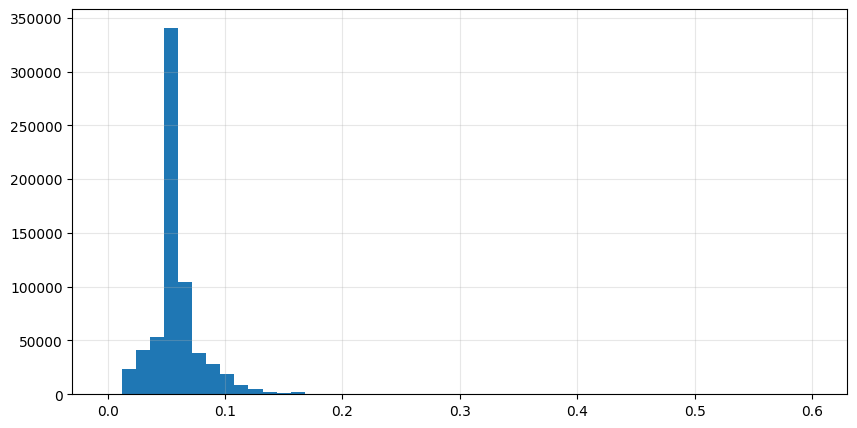

In [41]:
analysis_phys["cell_spread"].hist(bins=50)

<Axes: >

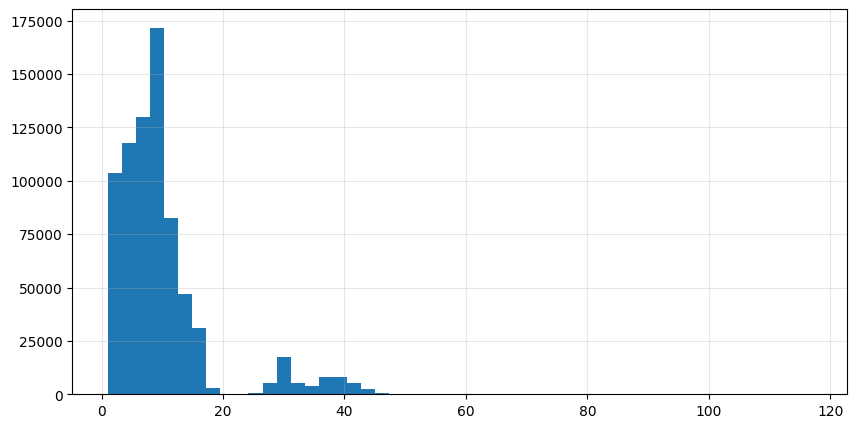

In [42]:
analysis_phys["temp_range"].hist(bins=50)

<Axes: >

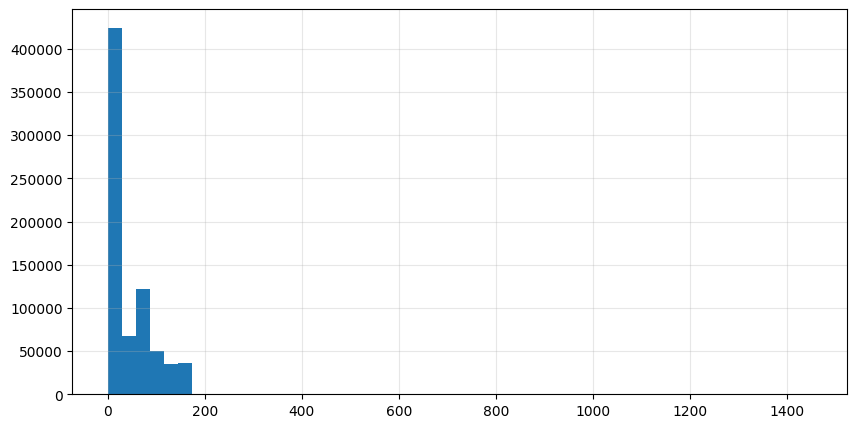

In [43]:
analysis_phys["abs_current"].hist(bins=50)

In [44]:
module_summary.set_index("module")[[
    "pct_lowest_voltage_module",
    "pct_hottest_module"
]].plot(kind="bar", figsize=(8,5))

NameError: name 'module_summary' is not defined

<Axes: xlabel='module'>

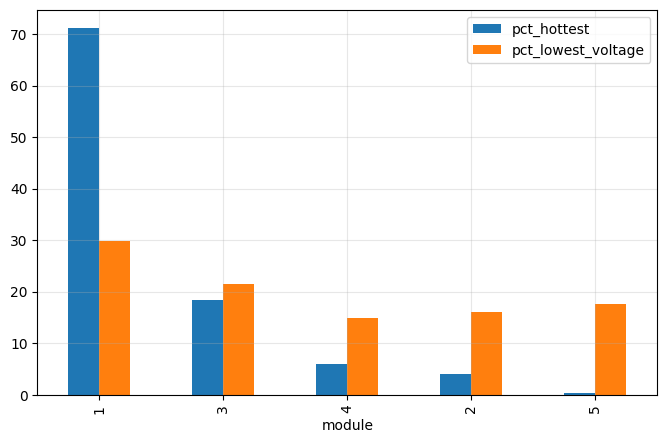

In [45]:
working_module_summary.set_index("module")[[
    "pct_hottest",
    "pct_lowest_voltage"
]].plot(kind="bar", figsize=(8,5))

/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_21833/757464831.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_phys.groupby("soc_band")["cell_spread"].mean().plot(marker='o')


<Axes: xlabel='soc_band'>

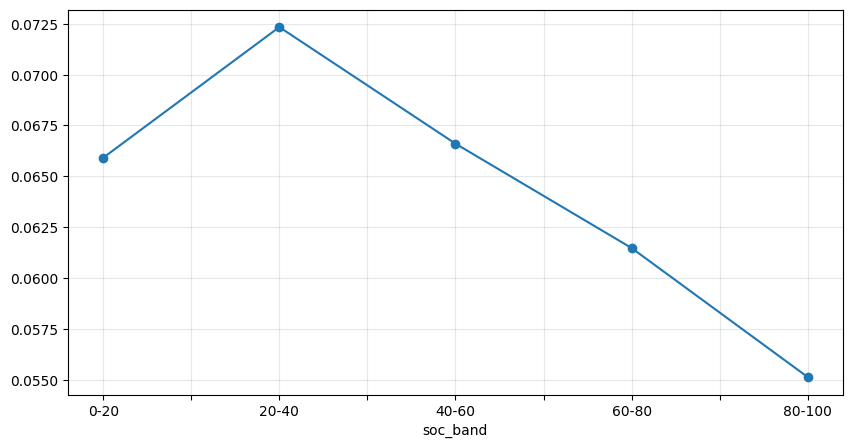

In [46]:
analysis_phys.groupby("soc_band")["cell_spread"].mean().plot(marker='o')

<Axes: xlabel='current_direction'>

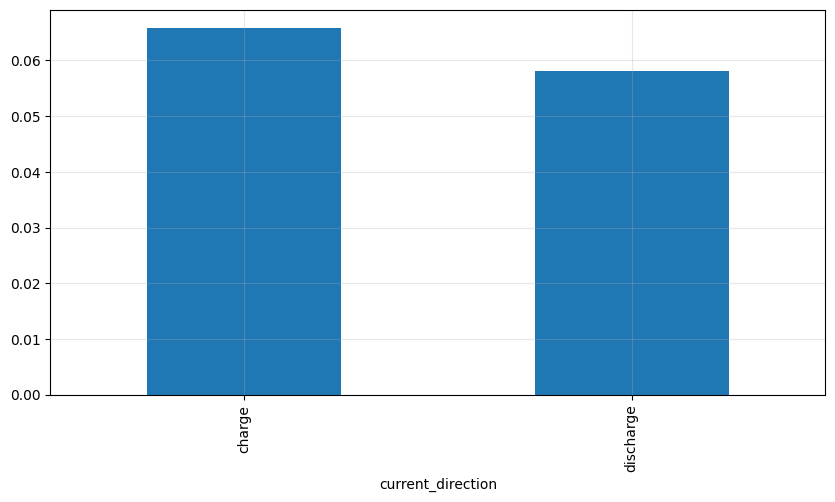

In [47]:
analysis_phys.groupby("current_direction")["cell_spread"].mean().plot(kind="bar")

<Axes: xlabel='date'>

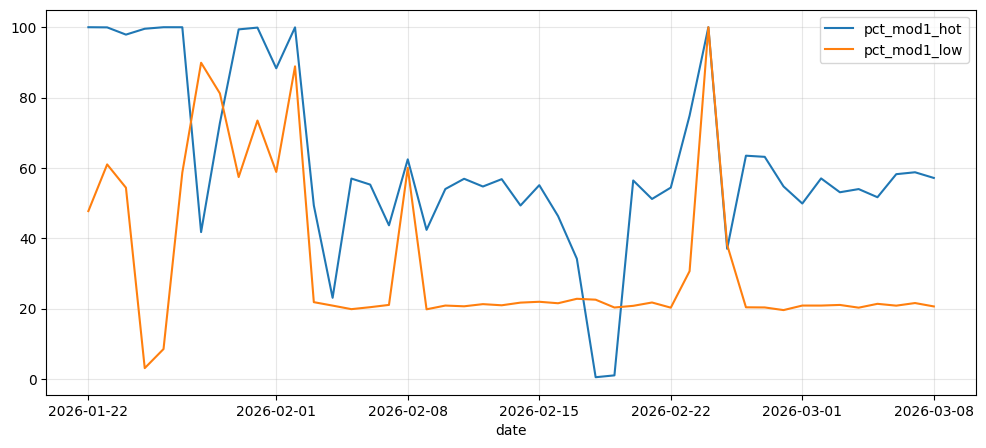

In [48]:
daily_mod1[["pct_mod1_hot", "pct_mod1_low"]].plot(figsize=(12,5))

<Axes: >

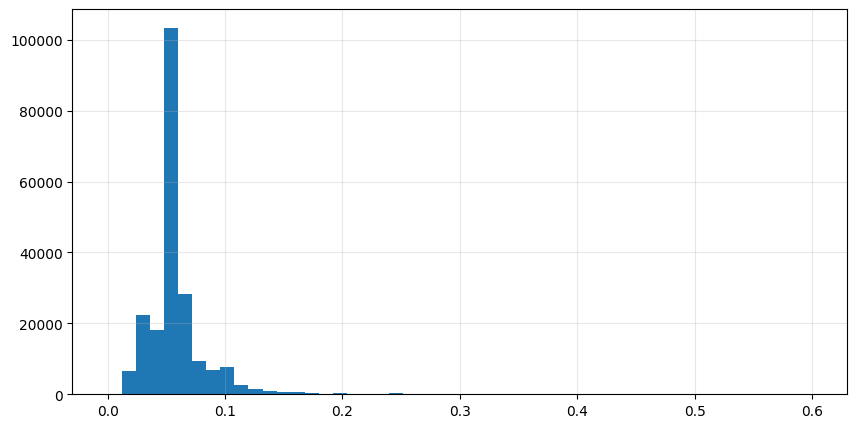

In [49]:
analysis_phys[analysis_phys["lowest_voltage_module"] == 1]["cell_spread"].hist(bins=50)

<Axes: xlabel='module_1_lowest_cell'>

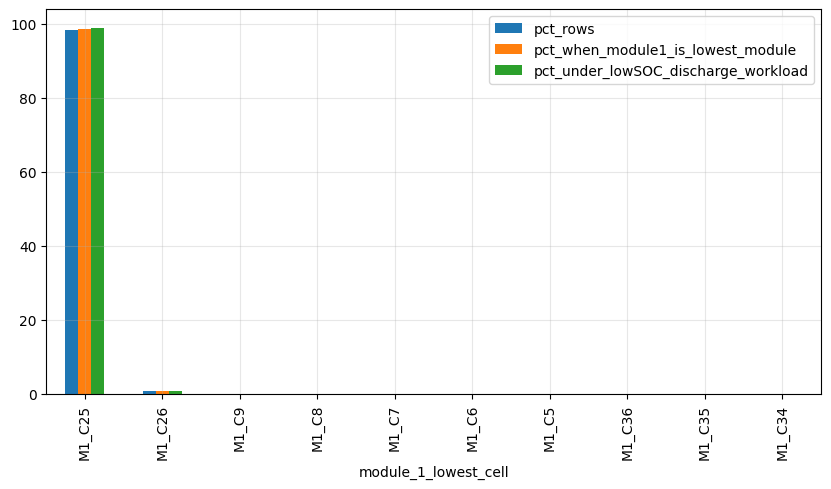

In [50]:
mod1_cell_compare.set_index("module_1_lowest_cell")[[
    "pct_rows",
    "pct_when_module1_is_lowest_module",
    "pct_under_lowSOC_discharge_workload"
]].head(10).plot(kind="bar", figsize=(10,5))

<Axes: >

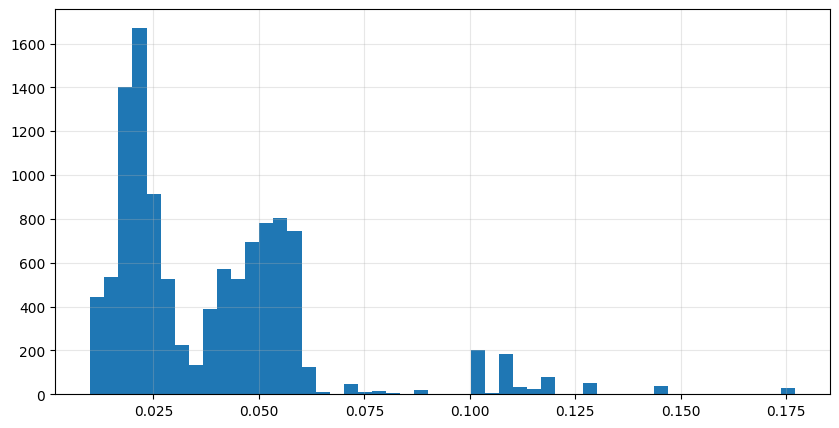

In [51]:
analysis_phys[
    analysis_phys["module_1_lowest_cell"] != "M1_C25"
]["cell_spread"].hist(bins=50)

In [54]:
import pandas as pd
import glob

path = "/Users/rhythmparashar/Desktop/ev-predictive-analytics/data/silver_cells/dt=*/vehicle_id=EV01.parquet"

files = glob.glob(path)

print("Total files:", len(files))

df_cells = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

# Convert timestamp
df_cells["timestamp"] = pd.to_datetime(df_cells["timestamp"], unit="ms", errors="coerce")

print("Shape:", df_cells.shape)
df_cells.head()

Total files: 39
Shape: (1397573, 273)


,timestamp,vehicle_id,M1_C1,M1_C2,M1_C3,M1_C4,M1_C5,M1_C6,M1_C7,M1_C8,M1_C9,M1_C10,M1_C11,M1_C12,M1_C13,M1_C14,M1_C15,M1_C16,M1_C17,M1_C18,M1_C19,M1_C20,M1_C21,M1_C22,M1_C23,M1_C24,M1_C25,M1_C26,M1_C27,M1_C28,M1_C29,M1_C30,M1_C31,M1_C32,M1_C33,M1_C34,M1_C35,M1_C36,M2_C1,M2_C2,M2_C3,M2_C4,M2_C5,M2_C6,M2_C7,M2_C8,M2_C9,M2_C10,M2_C11,M2_C12,M2_C13,M2_C14,M2_C15,M2_C16,M2_C17,M2_C18,M2_C19,M2_C20,M2_C21,M2_C22,...,M2_T14,M2_T15,M2_T16,M2_T17,M2_T18,M3_T1,M3_T2,M3_T3,M3_T4,M3_T5,M3_T6,M3_T7,M3_T8,M3_T9,M3_T10,M3_T11,M3_T12,M3_T13,M3_T14,M3_T15,M3_T16,M3_T17,M3_T18,M4_T1,M4_T2,M4_T3,M4_T4,M4_T5,M4_T6,M4_T7,M4_T8,M4_T9,M4_T10,M4_T11,M4_T12,M4_T13,M4_T14,M4_T15,M4_T16,M4_T17,M4_T18,M5_T1,M5_T2,M5_T3,M5_T4,M5_T5,M5_T6,M5_T7,M5_T8,M5_T9,M5_T10,M5_T11,M5_T12,M5_T13,M5_T14,M5_T15,M5_T16,M5_T17,M5_T18,cell_quality_flag
0,2026-03-05 00:00:00,EV01,3.295,3.297,3.297,3.297,3.311,3.311,3.312,3.312,3.304,3.304,3.304,3.304,3.309,3.311,3.311,3.311,3.306,3.306,3.306,3.307,3.311,3.311,3.310,3.310,3.256,3.260,3.320,3.312,3.310,3.310,3.310,3.310,3.307,3.306,3.306,3.306,3.309,3.312,3.311,3.311,3.311,3.311,3.312,3.312,3.311,3.311,3.310,3.310,3.306,3.307,3.307,3.307,3.297,3.297,3.297,3.297,3.312,3.312,...,36.0,36.0,36.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,35.0,37.0,36.0,36.0,29.0,34.0,36.0,36.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,35.0,36.0,36.0,36.0,29.0,34.0,36.0,36.0,36.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,35.0,36.0,37.0,36.0,29.0,28.0,36.0,36.0,35.0,35.0,29.0,0
1,2026-03-05 00:00:02,EV01,3.295,3.297,3.297,3.297,3.311,3.311,3.311,3.311,3.300,3.301,3.300,3.300,3.309,3.311,3.311,3.311,3.306,3.306,3.306,3.307,3.311,3.311,3.310,3.310,3.255,3.259,3.320,3.311,3.310,3.310,3.310,3.310,3.307,3.306,3.306,3.306,3.309,3.312,3.311,3.311,3.311,3.311,3.311,3.311,3.311,3.311,3.310,3.310,3.306,3.307,3.307,3.307,3.297,3.297,3.297,3.297,3.311,3.311,...,36.0,35.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,35.0,37.0,36.0,36.0,29.0,34.0,36.0,36.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,35.0,36.0,36.0,36.0,29.0,34.0,35.0,35.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,35.0,36.0,37.0,36.0,29.0,28.0,36.0,36.0,35.0,35.0,29.0,0
2,2026-03-05 00:00:04,EV01,3.295,3.297,3.297,3.297,3.298,3.298,3.298,3.298,3.300,3.301,3.300,3.300,3.299,3.300,3.300,3.300,3.306,3.306,3.306,3.307,3.299,3.298,3.298,3.298,3.255,3.259,3.320,3.311,3.299,3.299,3.299,3.298,3.307,3.306,3.306,3.306,3.296,3.299,3.299,3.298,3.311,3.311,3.311,3.311,3.299,3.299,3.299,3.299,3.306,3.307,3.307,3.307,3.297,3.297,3.297,3.297,3.299,3.298,...,36.0,36.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,35.0,37.0,36.0,36.0,29.0,34.0,36.0,36.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,35.0,36.0,36.0,36.0,29.0,34.0,35.0,35.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,36.0,36.0,36.0,36.0,29.0,28.0,36.0,36.0,35.0,35.0,29.0,0
3,2026-03-05 00:00:06,EV01,3.295,3.297,3.297,3.297,3.298,3.298,3.298,3.298,3.293,3.293,3.293,3.293,3.301,3.303,3.302,3.302,3.306,3.306,3.306,3.307,3.299,3.298,3.298,3.298,3.238,3.241,3.302,3.293,3.299,3.299,3.299,3.298,3.302,3.301,3.301,3.301,3.296,3.299,3.299,3.298,3.293,3.293,3.293,3.293,3.299,3.299,3.299,3.299,3.306,3.307,3.307,3.307,3.302,3.302,3.302,3.302,3.294,3.293,...,36.0,36.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,36.0,37.0,37.0,36.0,29.0,34.0,36.0,36.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,36.0,36.0,37.0,36.0,29.0,34.0,35.0,35.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,36.0,36.0,36.0,36.0,29.0,28.0,36.0,36.0,35.0,35.0,29.0,0
4,2026-03-05 00:00:08,EV01,3.288,3.290,3.289,3.289,3.298,3.298,3.298,3.298,3.293,3.293,3.293,3.293,3.288,3.288,3.288,3.288,3.289,3.289,3.289,3.290,3.299,3.298,3.298,3.298,3.238,3.241,3.302,3.293,3.299,3.299,3.299,3.298,3.287,3.286,3.286,3.286,3.296,3.299,3.299,3.298,3.293,3.293,3.293,3.293,3.299,3.299,3.299,3.299,3.288,3.288,3.288,3.288,3.289,3.289,3.289,3.290,3.294,3.293,...,36.0,36.0,35.0,35.0,29.0,36.0,35.0,28.0,35.0,36.0,29.0,37.0,36.0,37.0,37.0,36.0,29.0,34.0,36.0,36.0

In [55]:
mod1_cols = [c for c in df_cells.columns if c.startswith("M1_C")]

mod1_df = df_cells[["timestamp"] + mod1_cols].copy()

print("Total Module 1 cells:", len(mod1_cols))

Total Module 1 cells: 36


In [56]:
mod1_df = mod1_df.dropna(subset=mod1_cols, how="all")

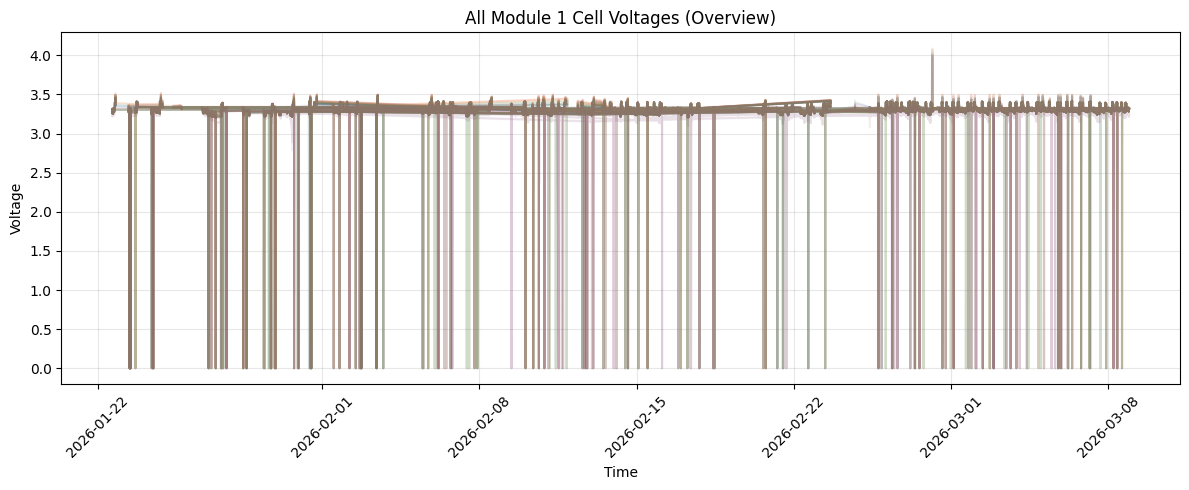

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for c in mod1_cols:
    plt.plot(mod1_df["timestamp"], mod1_df[c], alpha=0.1)

plt.title("All Module 1 Cell Voltages (Overview)")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_21833/414247148.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/rhythmparashar/Desktop/ev-predictive-analytics/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


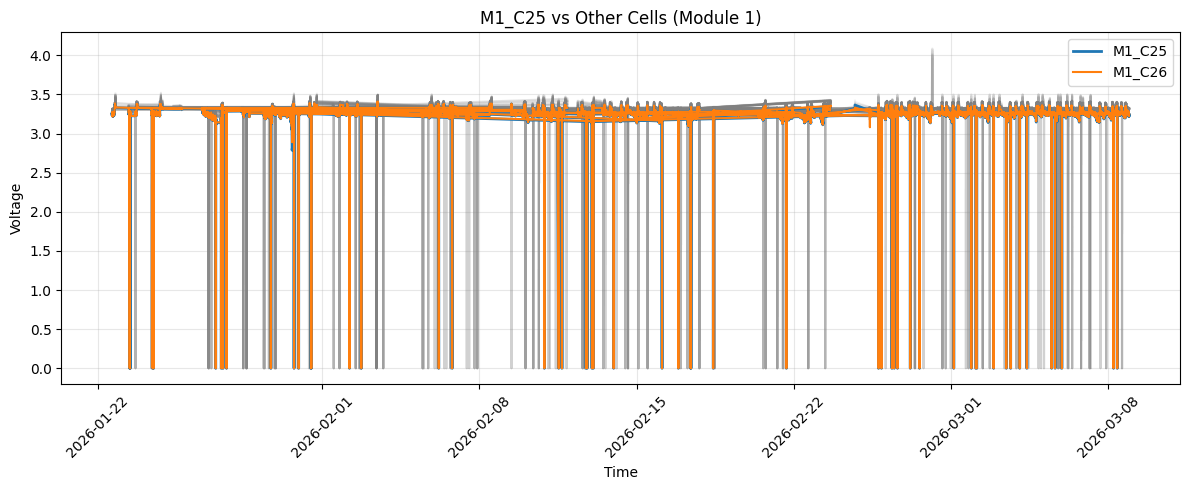

In [58]:
plt.figure(figsize=(12,5))

# Plot all cells faint
for c in mod1_cols:
    if c != "M1_C25":
        plt.plot(mod1_df["timestamp"], mod1_df[c], color="gray", alpha=0.1)

# Highlight C25
plt.plot(mod1_df["timestamp"], mod1_df["M1_C25"], label="M1_C25", linewidth=2)

# Optional: compare with C26
if "M1_C26" in mod1_cols:
    plt.plot(mod1_df["timestamp"], mod1_df["M1_C26"], label="M1_C26", linewidth=1.5)

plt.legend()
plt.title("M1_C25 vs Other Cells (Module 1)")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

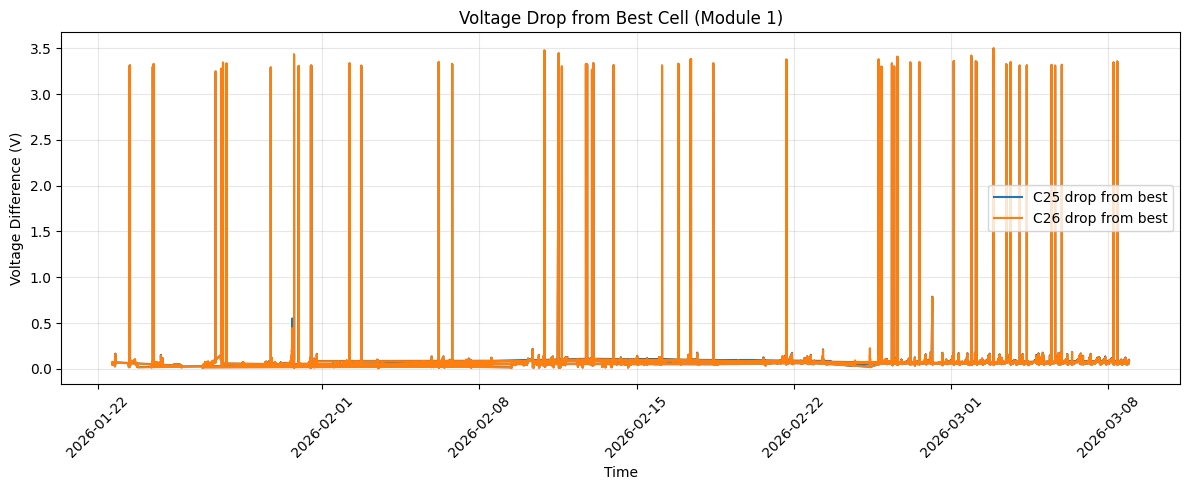

In [59]:
mod1_df["mod1_max"] = mod1_df[mod1_cols].max(axis=1)

plt.figure(figsize=(12,5))

plt.plot(
    mod1_df["timestamp"],
    mod1_df["mod1_max"] - mod1_df["M1_C25"],
    label="C25 drop from best",
)

if "M1_C26" in mod1_cols:
    plt.plot(
        mod1_df["timestamp"],
        mod1_df["mod1_max"] - mod1_df["M1_C26"],
        label="C26 drop from best",
    )

plt.legend()
plt.title("Voltage Drop from Best Cell (Module 1)")
plt.ylabel("Voltage Difference (V)")
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
mod1_df["lowest_cell"] = mod1_df[mod1_cols].idxmin(axis=1)

mod1_df["lowest_cell"].value_counts(normalize=True) * 100

lowest_cell
M1_C25    97.737253
M1_C26     0.882276
M1_C1      0.497618
M1_C9      0.141309
M1_C23     0.112816
M1_C5      0.097412
M1_C34     0.069931
M1_C29     0.061398
M1_C17     0.059734
M1_C13     0.058505
M1_C15     0.053226
M1_C18     0.038039
M1_C6      0.034279
M1_C32     0.033917
M1_C19     0.030735
M1_C21     0.023720
M1_C24     0.014897
M1_C14     0.011932
M1_C33     0.011643
M1_C8      0.010558
M1_C31     0.005352
M1_C7      0.004484
M1_C22     0.004122
M1_C11     0.001591
M1_C30     0.001302
M1_C10     0.001012
M1_C12     0.000434
M1_C36     0.000217
M1_C16     0.000217
M1_C35     0.000072
Name: proportion, dtype: float64

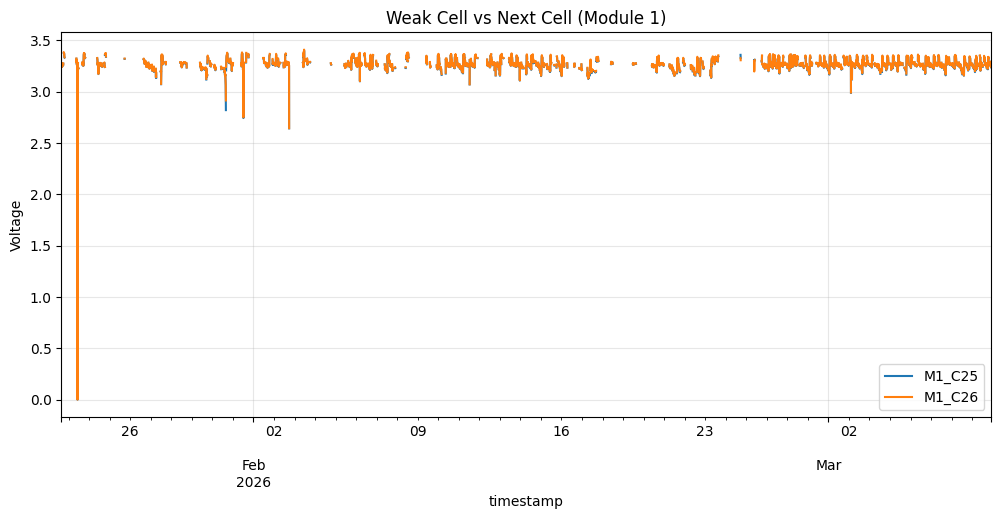

In [61]:
# Compare only key cells
key_cells = ["M1_C25", "M1_C26"]

df_cells.set_index("timestamp")[key_cells].resample("5min").mean().plot(figsize=(12,5))
plt.title("Weak Cell vs Next Cell (Module 1)")
plt.ylabel("Voltage")
plt.show()

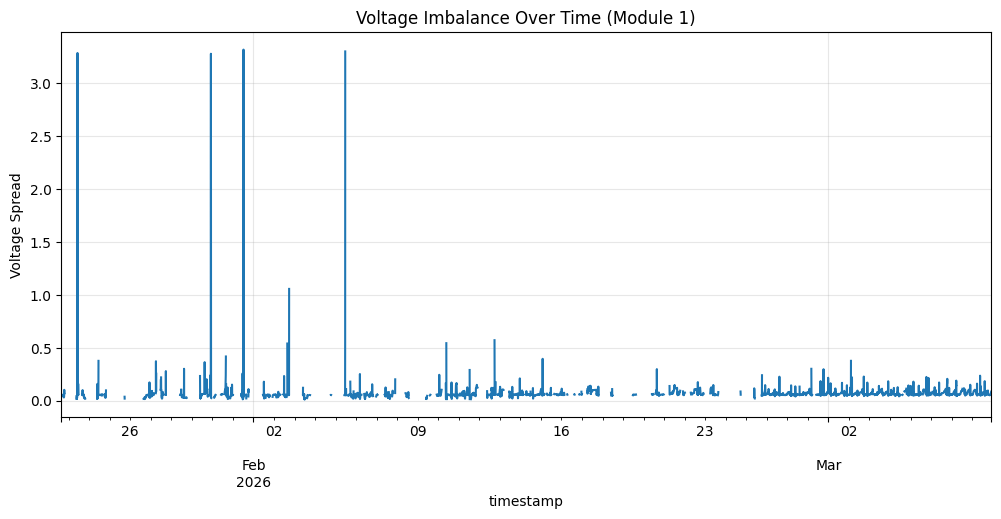

In [62]:
df_cells["M1_min"] = df_cells[[c for c in df_cells.columns if c.startswith("M1_C")]].min(axis=1)
df_cells["M1_max"] = df_cells[[c for c in df_cells.columns if c.startswith("M1_C")]].max(axis=1)

df_cells["spread"] = df_cells["M1_max"] - df_cells["M1_min"]

df_cells.set_index("timestamp")["spread"].resample("5min").mean().plot(figsize=(12,5))
plt.title("Voltage Imbalance Over Time (Module 1)")
plt.ylabel("Voltage Spread")
plt.show()

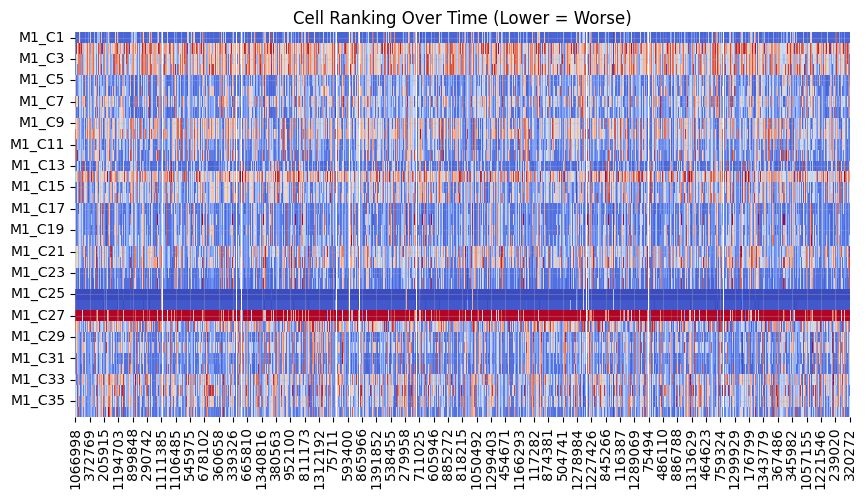

In [63]:
import seaborn as sns

subset = df_cells.sample(2000)

cell_cols = [c for c in df_cells.columns if c.startswith("M1_C")]

rank_df = subset[cell_cols].rank(axis=1, method="min")

sns.heatmap(rank_df.T, cmap="coolwarm", cbar=False)
plt.title("Cell Ranking Over Time (Lower = Worse)")
plt.show()

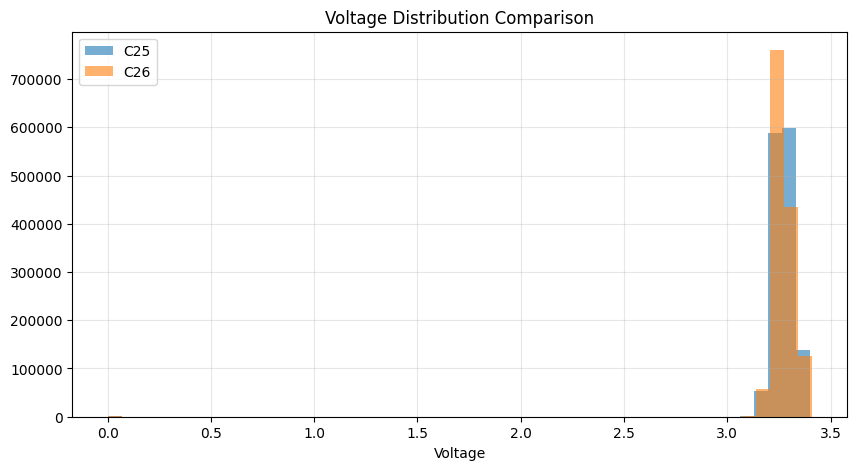

In [64]:
import matplotlib.pyplot as plt

df_cells["M1_C25"].dropna().hist(bins=50, alpha=0.6, label="C25")
df_cells["M1_C26"].dropna().hist(bins=50, alpha=0.6, label="C26")

plt.legend()
plt.title("Voltage Distribution Comparison")
plt.xlabel("Voltage")
plt.show()

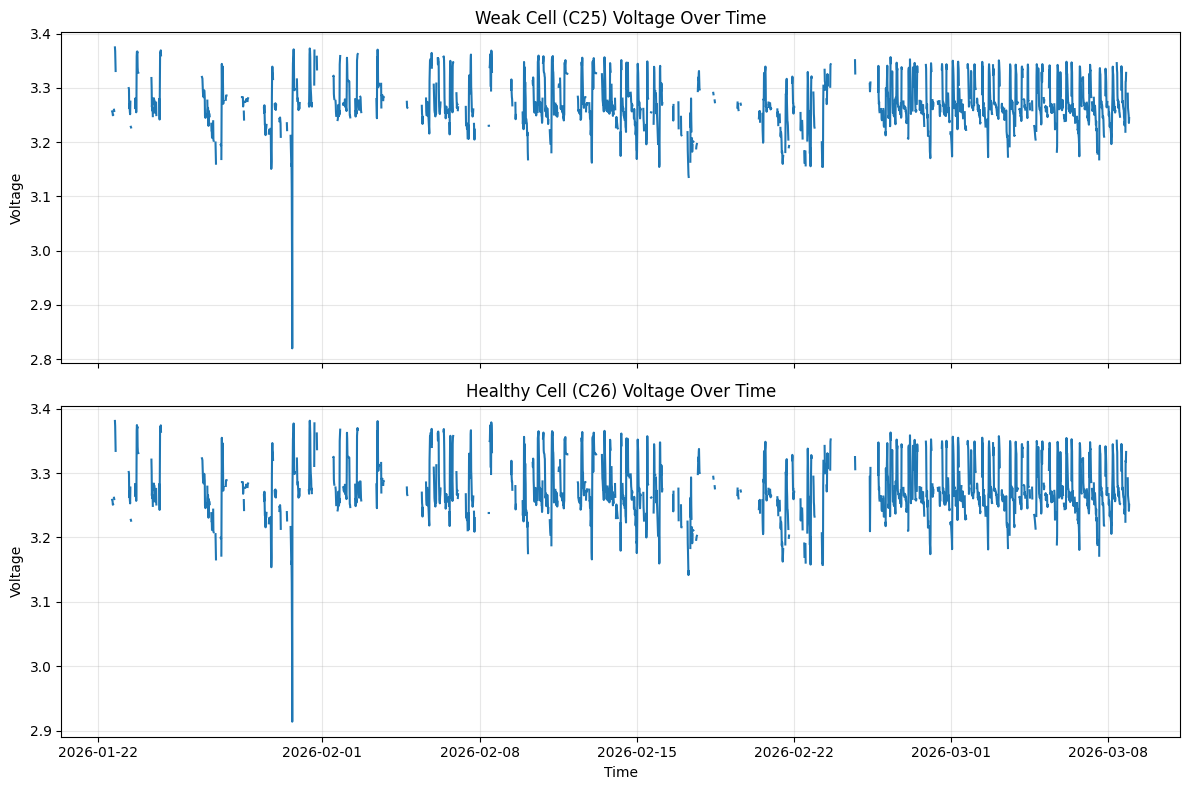

In [65]:
import matplotlib.pyplot as plt

df_plot = df_cells.replace(0, np.nan).set_index("timestamp")[["M1_C25", "M1_C26"]].resample("15min").mean()

fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top: C25 (weak cell)
axes[0].plot(df_plot.index, df_plot["M1_C25"])
axes[0].set_title("Weak Cell (C25) Voltage Over Time")
axes[0].set_ylabel("Voltage")

# Bottom: C26 (comparison cell)
axes[1].plot(df_plot.index, df_plot["M1_C26"])
axes[1].set_title("Healthy Cell (C26) Voltage Over Time")
axes[1].set_ylabel("Voltage")

plt.xlabel("Time")
plt.tight_layout()
plt.show()

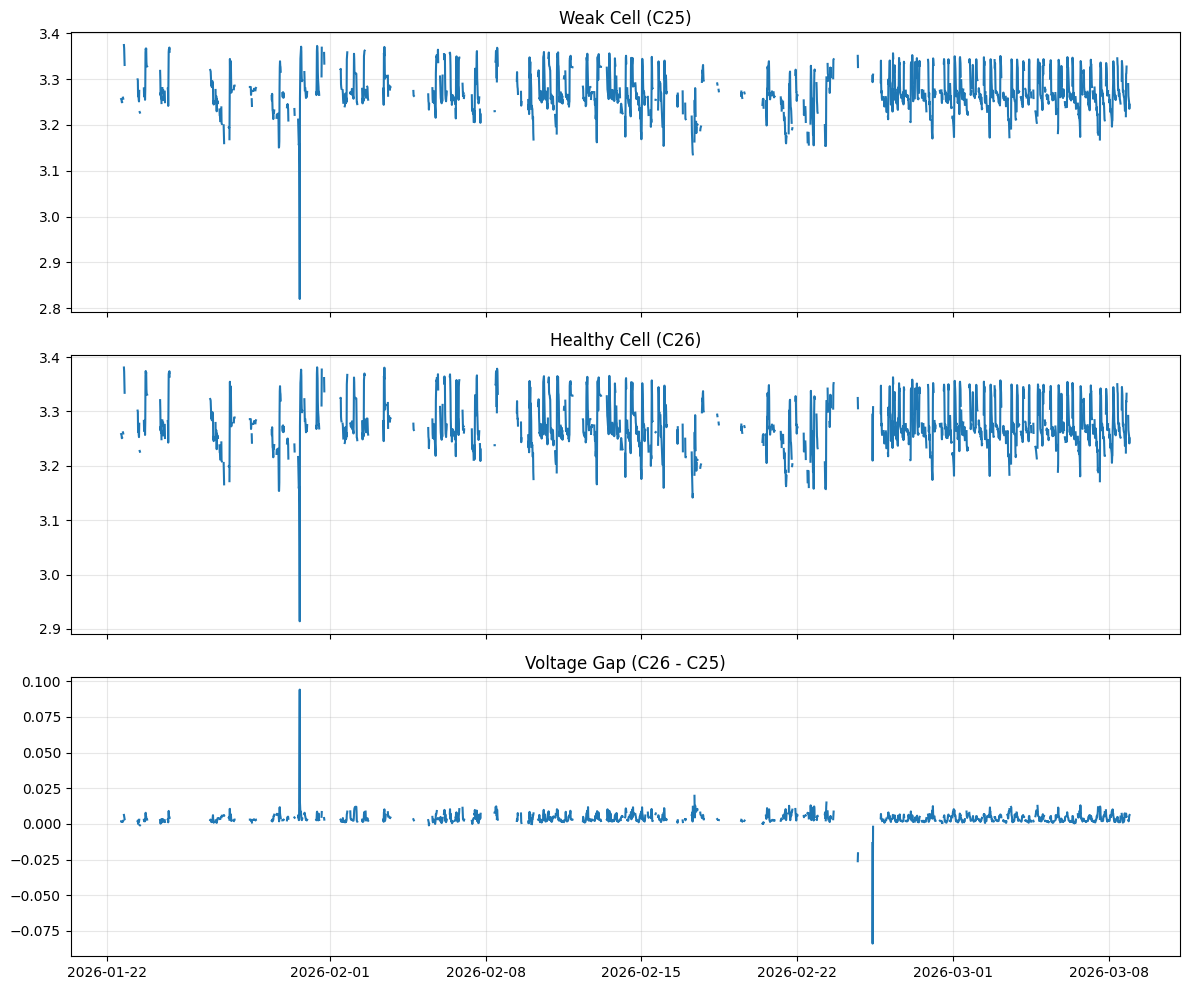

In [66]:
df_plot["diff"] = df_plot["M1_C26"] - df_plot["M1_C24"]

fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True)

axes[0].plot(df_plot.index, df_plot["M1_C25"])
axes[0].set_title("Weak Cell (C25)")

axes[1].plot(df_plot.index, df_plot["M1_C26"])
axes[1].set_title("Healthy Cell (C26)")

axes[2].plot(df_plot.index, df_plot["diff"])
axes[2].set_title("Voltage Gap (C26 - C25)")

plt.tight_layout()
plt.show()

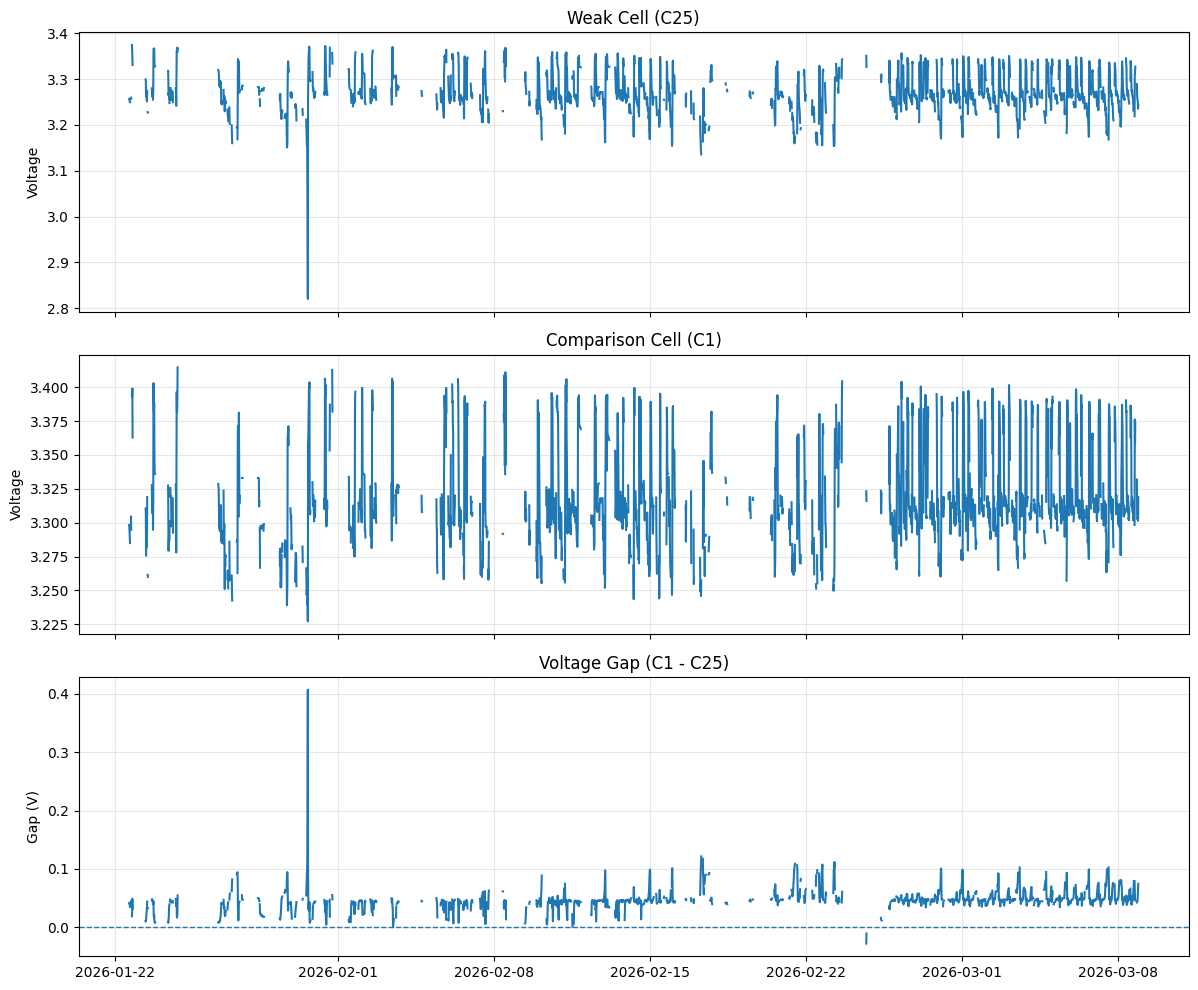

In [67]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_cells.copy().replace(0, np.nan)
cols = ["M1_C25", "M1_C1"]
df_plot = df_plot.set_index("timestamp")[cols].resample("15min").mean()

df_plot["gap"] = df_plot["M1_C1"] - df_plot["M1_C25"]

fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True)

axes[0].plot(df_plot.index, df_plot["M1_C25"])
axes[0].set_title("Weak Cell (C25)")
axes[0].set_ylabel("Voltage")

axes[1].plot(df_plot.index, df_plot["M1_C1"])
axes[1].set_title("Comparison Cell (C1)")
axes[1].set_ylabel("Voltage")

axes[2].plot(df_plot.index, df_plot["gap"])
axes[2].set_title("Voltage Gap (C1 - C25)")
axes[2].set_ylabel("Gap (V)")
axes[2].axhline(0, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [ ]:
import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages

# =========================================================
# 1. CONFIG
# =========================================================
TIME_GAP_MIN = 5
SMOOTH_WINDOW = 15
MIN_POINTS_PER_TRIP = 20

OUTPUT_DIR = "internal_analysis_report"
PLOTS_DIR = os.path.join(OUTPUT_DIR, "trip_plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

PARAMS = [
    ("Motor Temperature (°C)", "Motor Temperature", "°C"),
    ("MCU Temperature (°C)", "Controller Temperature", "°C"),
    ("Motor AC Current (A)", "Motor Current", "A"),
    ("Motor AC Voltage (V)", "Motor Voltage", "V"),
    ("Motor Total Wattage (W)", "Motor Power", "W"),
]

# =========================================================
# 2. PREPARE DATA
# =========================================================
df = df.copy()

df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

df["time_diff_min"] = df["Timestamp"].diff().dt.total_seconds() / 60
df["Trip_ID"] = ((df["time_diff_min"].isna()) | (df["time_diff_min"] > TIME_GAP_MIN)).cumsum()

df["Trip_Time_Min"] = df.groupby("Trip_ID")["Timestamp"].transform(
    lambda x: (x - x.iloc[0]).dt.total_seconds() / 60
)

# =========================================================
# 3. STYLE
# =========================================================
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 14),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "font.size": 10,
    "legend.fontsize": 9,
    "lines.linewidth": 2.0,
    "grid.alpha": 0.35,
    "savefig.dpi": 300,
})

COLORS = {
    "Motor Temperature": "#C0392B",
    "Controller Temperature": "#E67E22",
    "Motor Current": "#1F77B4",
    "Motor Voltage": "#2E8B57",
    "Motor Power": "#6A3D9A",
}

# =========================================================
# 4. HELPER FUNCTIONS
# =========================================================
def add_smoothed_columns(trip_df, window=SMOOTH_WINDOW):
    trip_df = trip_df.copy()
    for col, _, _ in PARAMS:
        trip_df[f"{col}_Smooth"] = trip_df[col].rolling(window=window, min_periods=1).mean()
    return trip_df


def generate_trip_insights(trip_df, summary_row):
    insights = []

    motor_temp_max = summary_row["Motor Temperature_max"]
    motor_temp_avg = summary_row["Motor Temperature_avg"]
    ctrl_temp_max = summary_row["Controller Temperature_max"]
    current_max = summary_row["Motor Current_max"]
    voltage_avg = summary_row["Motor Voltage_avg"]
    power_max = summary_row["Motor Power_max"]
    duration = summary_row["Duration_min"]

    if motor_temp_max >= 85:
        insights.append("Motor temperature reached a high thermal zone and should be reviewed for sustained heavy-duty loading.")
    elif motor_temp_max >= 70:
        insights.append("Motor temperature remained elevated during the trip, indicating moderate-to-high thermal loading.")
    else:
        insights.append("Motor temperature remained within a controlled operating range for this trip.")

    if ctrl_temp_max >= 75:
        insights.append("Controller temperature was relatively high, suggesting the inverter/controller was under significant electrical load.")
    else:
        insights.append("Controller temperature remained stable, indicating healthy control-side thermal behavior.")

    if current_max >= 250:
        insights.append("High peak motor current suggests demanding excavation or aggressive load events.")
    elif current_max >= 150:
        insights.append("Motor current indicates moderate working load during the trip.")
    else:
        insights.append("Motor current stayed relatively low, suggesting light-duty operation or idle/transit behavior.")

    if voltage_avg >= 300:
        insights.append("Average motor voltage indicates the machine spent a meaningful portion of time in a higher-speed operating region.")
    else:
        insights.append("Average motor voltage indicates predominantly lower-speed operation.")

    if power_max >= 80000:
        insights.append("A strong peak power event was observed, consistent with a heavy-duty work segment.")
    elif power_max >= 40000:
        insights.append("Peak power demand was moderate and consistent with typical machine operation.")
    else:
        insights.append("Power demand stayed relatively low throughout this trip.")

    if duration < 5:
        insights.append("This was a short trip and should be interpreted as a transient operating event.")
    elif duration > 30:
        insights.append("This was a long continuous trip and is useful for assessing stability over extended operation.")

    if motor_temp_avg > 0 and current_max > 0:
        insights.append("Overall, the trip can be used to compare thermal response against electrical loading and identify whether heat rise tracked sustained current demand.")

    return " ".join(insights)


def generate_session_insights(overall_summary):
    insights = []

    if overall_summary["Motor Temperature_max"] >= 85:
        insights.append("Across the full session, motor temperature entered a high thermal zone at least once.")
    else:
        insights.append("Across the full session, motor temperature remained within a generally controlled range.")

    if overall_summary["Controller Temperature_max"] >= 75:
        insights.append("Controller thermal loading was notable during at least one segment of the session.")
    else:
        insights.append("Controller temperature stayed broadly stable across the session.")

    if overall_summary["Motor Current_max"] >= 250:
        insights.append("The session included high-load electrical events, likely corresponding to demanding work cycles.")
    else:
        insights.append("The session did not show extreme motor current demand.")

    if overall_summary["Motor Power_max"] >= 80000:
        insights.append("Peak motor power indicates at least one heavy-duty event during the session.")
    else:
        insights.append("Overall power demand remained in a moderate range.")

    insights.append("The trip-wise comparison should be used to identify which operating cycles contributed most to heating, electrical stress, and peak demand.")

    return " ".join(insights)


def make_combined_trip_plot(trip_df, trip_id, output_path):
    trip_df = add_smoothed_columns(trip_df)

    start_time = trip_df["Timestamp"].iloc[0]
    end_time = trip_df["Timestamp"].iloc[-1]
    duration_min = (end_time - start_time).total_seconds() / 60

    fig, axes = plt.subplots(len(PARAMS), 1, sharex=True, figsize=(12, 14))

    for ax, (col, label, unit) in zip(axes, PARAMS):
        color = COLORS[label]

        ax.plot(
            trip_df["Trip_Time_Min"],
            trip_df[col],
            color=color,
            alpha=0.25,
            linewidth=1.0,
            label="Raw"
        )
        ax.plot(
            trip_df["Trip_Time_Min"],
            trip_df[f"{col}_Smooth"],
            color=color,
            alpha=0.95,
            linewidth=2.4,
            label="Smoothed"
        )

        ax.set_ylabel(f"{label}\n({unit})")
        ax.set_title(f"{label} vs Time", loc="left")
        ax.legend(loc="upper right", frameon=True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Time Into Trip (minutes)")

    fig.suptitle(
        f"Trip {trip_id} - Motor System Trend Comparison\n"
        f"Start: {start_time:%Y-%m-%d %H:%M:%S} | End: {end_time:%Y-%m-%d %H:%M:%S} | Duration: {duration_min:.1f} min",
        fontsize=14,
        fontweight="bold",
        y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.975])
    plt.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


def add_wrapped_text_page(pdf, title, body_lines, fontsize=11):
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.patch.set_facecolor("white")
    plt.axis("off")

    plt.text(0.06, 0.95, title, fontsize=18, fontweight="bold", va="top")

    y = 0.90
    line_step = 0.028

    for block in body_lines:
        wrapped = textwrap.wrap(block, width=105) if block else [""]
        for line in wrapped:
            plt.text(0.06, y, line, fontsize=fontsize, va="top")
            y -= line_step
            if y < 0.06:
                pdf.savefig(fig, bbox_inches="tight")
                plt.close(fig)
                fig = plt.figure(figsize=(8.27, 11.69))
                fig.patch.set_facecolor("white")
                plt.axis("off")
                y = 0.95

        y -= 0.012

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def add_table_page(pdf, title, table_df, col_widths=None, fontsize=9):
    fig, ax = plt.subplots(figsize=(8.27, 11.69))
    fig.patch.set_facecolor("white")
    ax.axis("off")

    ax.text(0.02, 0.98, title, fontsize=16, fontweight="bold", va="top", transform=ax.transAxes)

    display_df = table_df.copy()

    for c in display_df.columns:
        if pd.api.types.is_datetime64_any_dtype(display_df[c]):
            display_df[c] = display_df[c].dt.strftime("%Y-%m-%d %H:%M:%S")
        elif pd.api.types.is_float_dtype(display_df[c]):
            display_df[c] = display_df[c].round(2)

    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc="center",
        colLoc="center",
        loc="upper left",
        bbox=[0.02, 0.05, 0.96, 0.88],
        colWidths=col_widths
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor("#2F4F4F")
        else:
            cell.set_facecolor("#F8F9FA" if row % 2 == 0 else "white")

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


# =========================================================
# 5. TRIP-WISE SUMMARY
# =========================================================
trip_summaries = []
plot_paths = []

for trip_id, trip_df in df.groupby("Trip_ID"):
    if len(trip_df) < MIN_POINTS_PER_TRIP:
        continue

    start_time = trip_df["Timestamp"].iloc[0]
    end_time = trip_df["Timestamp"].iloc[-1]
    duration_min = (end_time - start_time).total_seconds() / 60

    summary = {
        "Trip_ID": trip_id,
        "Start_Time": start_time,
        "End_Time": end_time,
        "Duration_min": round(duration_min, 2),
        "Samples": len(trip_df),
    }

    for col, label, unit in PARAMS:
        summary[f"{label}_max"] = trip_df[col].max()
        summary[f"{label}_min"] = trip_df[col].min()
        summary[f"{label}_avg"] = trip_df[col].mean()

    trip_summaries.append(summary)

    plot_path = os.path.join(PLOTS_DIR, f"Trip_{trip_id}_combined.png")
    make_combined_trip_plot(trip_df, trip_id, plot_path)
    plot_paths.append((trip_id, plot_path))

trip_summary_df = pd.DataFrame(trip_summaries)

if trip_summary_df.empty:
    raise ValueError("No trips found with enough data points. Reduce MIN_POINTS_PER_TRIP or inspect the dataset.")

trip_summary_df["Key_Insights"] = trip_summary_df.apply(
    lambda row: generate_trip_insights(
        df[df["Trip_ID"] == row["Trip_ID"]], row
    ),
    axis=1
)

# =========================================================
# 6. OVERALL SESSION SUMMARY
# =========================================================
overall_summary = {
    "Total_Trips": int(trip_summary_df["Trip_ID"].nunique()),
    "Session_Start": df["Timestamp"].min(),
    "Session_End": df["Timestamp"].max(),
    "Session_Duration_min": round((df["Timestamp"].max() - df["Timestamp"].min()).total_seconds() / 60, 2),
    "Total_Samples": len(df),
}

for col, label, unit in PARAMS:
    overall_summary[f"{label}_max"] = df[col].max()
    overall_summary[f"{label}_min"] = df[col].min()
    overall_summary[f"{label}_avg"] = df[col].mean()

overall_insights = generate_session_insights(overall_summary)

overall_summary_df = pd.DataFrame([overall_summary])

# =========================================================
# 7. SAVE EXCEL/CSV TABLES
# =========================================================
trip_summary_csv = os.path.join(OUTPUT_DIR, "trip_summary.csv")
overall_summary_csv = os.path.join(OUTPUT_DIR, "overall_session_summary.csv")

trip_summary_df.to_csv(trip_summary_csv, index=False)
overall_summary_df.to_csv(overall_summary_csv, index=False)

# Also save a compact trip table for report readability
compact_cols = [
    "Trip_ID", "Start_Time", "End_Time", "Duration_min", "Samples",
    "Motor Temperature_max", "Motor Temperature_avg",
    "Controller Temperature_max", "Controller Temperature_avg",
    "Motor Current_max", "Motor Current_avg",
    "Motor Voltage_max", "Motor Voltage_avg",
    "Motor Power_max", "Motor Power_avg"
]
compact_trip_df = trip_summary_df[compact_cols].copy()

# =========================================================
# 8. BUILD PDF REPORT
# =========================================================
pdf_path = os.path.join(OUTPUT_DIR, "Internal_Motor_Analysis_Report.pdf")

with PdfPages(pdf_path) as pdf:
    # Title page
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.patch.set_facecolor("white")
    plt.axis("off")

    plt.text(0.5, 0.80, "Internal Analysis Report", ha="center", fontsize=24, fontweight="bold")
    plt.text(0.5, 0.74, "Excavator Motor Thermal and Electrical Performance", ha="center", fontsize=16)
    plt.text(0.5, 0.67, f"Session Start: {overall_summary['Session_Start']:%Y-%m-%d %H:%M:%S}", ha="center", fontsize=11)
    plt.text(0.5, 0.64, f"Session End: {overall_summary['Session_End']:%Y-%m-%d %H:%M:%S}", ha="center", fontsize=11)
    plt.text(0.5, 0.61, f"Total Trips Analysed: {overall_summary['Total_Trips']}", ha="center", fontsize=11)
    plt.text(0.5, 0.58, f"Session Duration: {overall_summary['Session_Duration_min']:.2f} minutes", ha="center", fontsize=11)

    plt.text(
        0.08, 0.48,
        "Objective\n"
        "This document summarises trip-wise and session-level motor thermal and electrical behaviour.\n"
        "Trips are segmented using a timestamp gap greater than 5 minutes. Each trip includes trend plots,\n"
        "summary statistics, and interpretation intended for internal engineering review.",
        fontsize=12, va="top"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Methodology page
    add_wrapped_text_page(
        pdf,
        "Methodology",
        [
            "1. Timestamps were converted to datetime and sorted chronologically.",
            "2. A new trip was created whenever the gap between consecutive timestamps exceeded 5 minutes.",
            "3. For each trip, five key parameters were plotted against time: motor temperature, controller temperature, motor current, motor voltage, and motor power.",
            "4. Both raw and smoothed curves were shown. Smoothing was applied using a rolling average to make trends easier to interpret in a report setting.",
            "5. For each trip, max, min, average, duration, and observations were computed. The same was then computed for the full session."
        ],
        fontsize=11
    )

    # Overall summary page
    overall_table = overall_summary_df.T.reset_index()
    overall_table.columns = ["Metric", "Value"]
    add_table_page(pdf, "Overall Session Summary", overall_table, fontsize=10)

    # Overall insight page
    add_wrapped_text_page(
        pdf,
        "Overall Session Insights",
        [overall_insights],
        fontsize=11
    )

    # Compact trip summary table
    add_table_page(pdf, "Trip Summary Table", compact_trip_df, fontsize=8)

    # Per-trip pages
    for _, row in trip_summary_df.iterrows():
        trip_id = row["Trip_ID"]
        trip_table = pd.DataFrame({
            "Metric": [
                "Trip ID", "Start Time", "End Time", "Duration (min)", "Samples",
                "Motor Temperature Max", "Motor Temperature Min", "Motor Temperature Avg",
                "Controller Temperature Max", "Controller Temperature Min", "Controller Temperature Avg",
                "Motor Current Max", "Motor Current Min", "Motor Current Avg",
                "Motor Voltage Max", "Motor Voltage Min", "Motor Voltage Avg",
                "Motor Power Max", "Motor Power Min", "Motor Power Avg"
            ],
            "Value": [
                row["Trip_ID"], row["Start_Time"], row["End_Time"], row["Duration_min"], row["Samples"],
                round(row["Motor Temperature_max"], 2), round(row["Motor Temperature_min"], 2), round(row["Motor Temperature_avg"], 2),
                round(row["Controller Temperature_max"], 2), round(row["Controller Temperature_min"], 2), round(row["Controller Temperature_avg"], 2),
                round(row["Motor Current_max"], 2), round(row["Motor Current_min"], 2), round(row["Motor Current_avg"], 2),
                round(row["Motor Voltage_max"], 2), round(row["Motor Voltage_min"], 2), round(row["Motor Voltage_avg"], 2),
                round(row["Motor Power_max"], 2), round(row["Motor Power_min"], 2), round(row["Motor Power_avg"], 2),
            ]
        })
        add_table_page(pdf, f"Trip {trip_id} Summary Statistics", trip_table, fontsize=10)

        add_wrapped_text_page(
            pdf,
            f"Trip {trip_id} Key Insights",
            [row["Key_Insights"]],
            fontsize=11
        )

        # plot page
        fig = plt.figure(figsize=(8.27, 11.69))
        fig.patch.set_facecolor("white")
        plt.axis("off")
        img = plt.imread(os.path.join(PLOTS_DIR, f"Trip_{trip_id}_combined.png"))
        plt.imshow(img)
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

# =========================================================
# 9. OPTIONAL EXCEL REPORT
# =========================================================
excel_path = os.path.join(OUTPUT_DIR, "Internal_Motor_Analysis_Report.xlsx")
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    trip_summary_df.to_excel(writer, sheet_name="Trip Summary", index=False)
    overall_summary_df.to_excel(writer, sheet_name="Overall Summary", index=False)

print("Done.")
print("Trip summary CSV:", trip_summary_csv)
print("Overall summary CSV:", overall_summary_csv)
print("Excel report:", excel_path)
print("PDF report:", pdf_path)
print("Trip plots folder:", PLOTS_DIR)